In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from numba import jit
import scipy
import pandas as pd
import seaborn as sns
import os
from scipy.ndimage import uniform_filter1d
from plotting import *

In [3]:
planets = pd.read_csv("../input/planets_triple.csv")

In [4]:
triples = pd.read_csv('../input/final_triple_5.csv')

In [5]:
from integrator import run_system
from integrator.experiments import generate_habitability_experiments
from integrator.batch import recommended_dt

In [6]:
configs = generate_habitability_experiments(
    triples,
    planets,
    tf=1e5,
    output_dir='../output',
)

# Compute dt and output cadence for each config
for cfg in configs:
    cfg["dt"] = recommended_dt(cfg)
    cfg["output_every_n"] = max(1, int(1.0 / cfg["dt"]))  # ~1 snapshot per year

print(f"Generated {len(configs)} experiment configs")
print(f"tf = {configs[0]['tf']:.0f} yr")
print(f"Example dt = {configs[0]['dt']:.6g} yr")
print(f"Example output_every_n = {configs[0]['output_every_n']}")
print(f"Example snapshots = {int(configs[0]['tf'] / configs[0]['dt'] / configs[0]['output_every_n'])}")

Generated 101 experiment configs
tf = 100000 yr
Example dt = 0.00203401 yr
Example output_every_n = 491
Example snapshots = 100130


In [7]:
# --- Post-processing: compute orbital elements, energy, temperature, HZ ---
from integrator import postprocess

for i, cfg in enumerate(configs):
    path = cfg['output_file']
    if os.path.exists(path):
        print(f"[{i+1}/{len(configs)}] Post-processing: {cfg['experiment_name']}")
        try:
            postprocess(path)
        except Exception as exc:
            print(f"  FAIL: {exc}")
    else:
        print(f"[{i+1}/{len(configs)}] Missing: {cfg['experiment_name']}")

print("Post-processing complete.")

[1/101] Post-processing: Gliese_667_observed_ev0.0_iv000
  ../output/Gliese_667_observed_ev0.0_iv000.hdf5: already post-processed, skipping
[2/101] Post-processing: Gliese_667_observed_ev0.0_iv030
  ../output/Gliese_667_observed_ev0.0_iv030.hdf5: already post-processed, skipping
[3/101] Post-processing: Gliese_667_observed_ev0.0_iv060
  ../output/Gliese_667_observed_ev0.0_iv060.hdf5: already post-processed, skipping
[4/101] Post-processing: Gliese_667_observed_ev0.0_iv090
  ../output/Gliese_667_observed_ev0.0_iv090.hdf5: already post-processed, skipping
[5/101] Post-processing: Gliese_667_observed_ev0.2_iv000
  ../output/Gliese_667_observed_ev0.2_iv000.hdf5: already post-processed, skipping
[6/101] Post-processing: Gliese_667_observed_ev0.2_iv030
  ../output/Gliese_667_observed_ev0.2_iv030.hdf5: already post-processed, skipping
[7/101] Post-processing: Gliese_667_observed_ev0.2_iv060
  ../output/Gliese_667_observed_ev0.2_iv060.hdf5: already post-processed, skipping
[8/101] Post-process

skipped ../output/Gliese_667_observed_ev0.0_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.0_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.0_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.0_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.8_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.8_iv030.hdf5
skipped ..

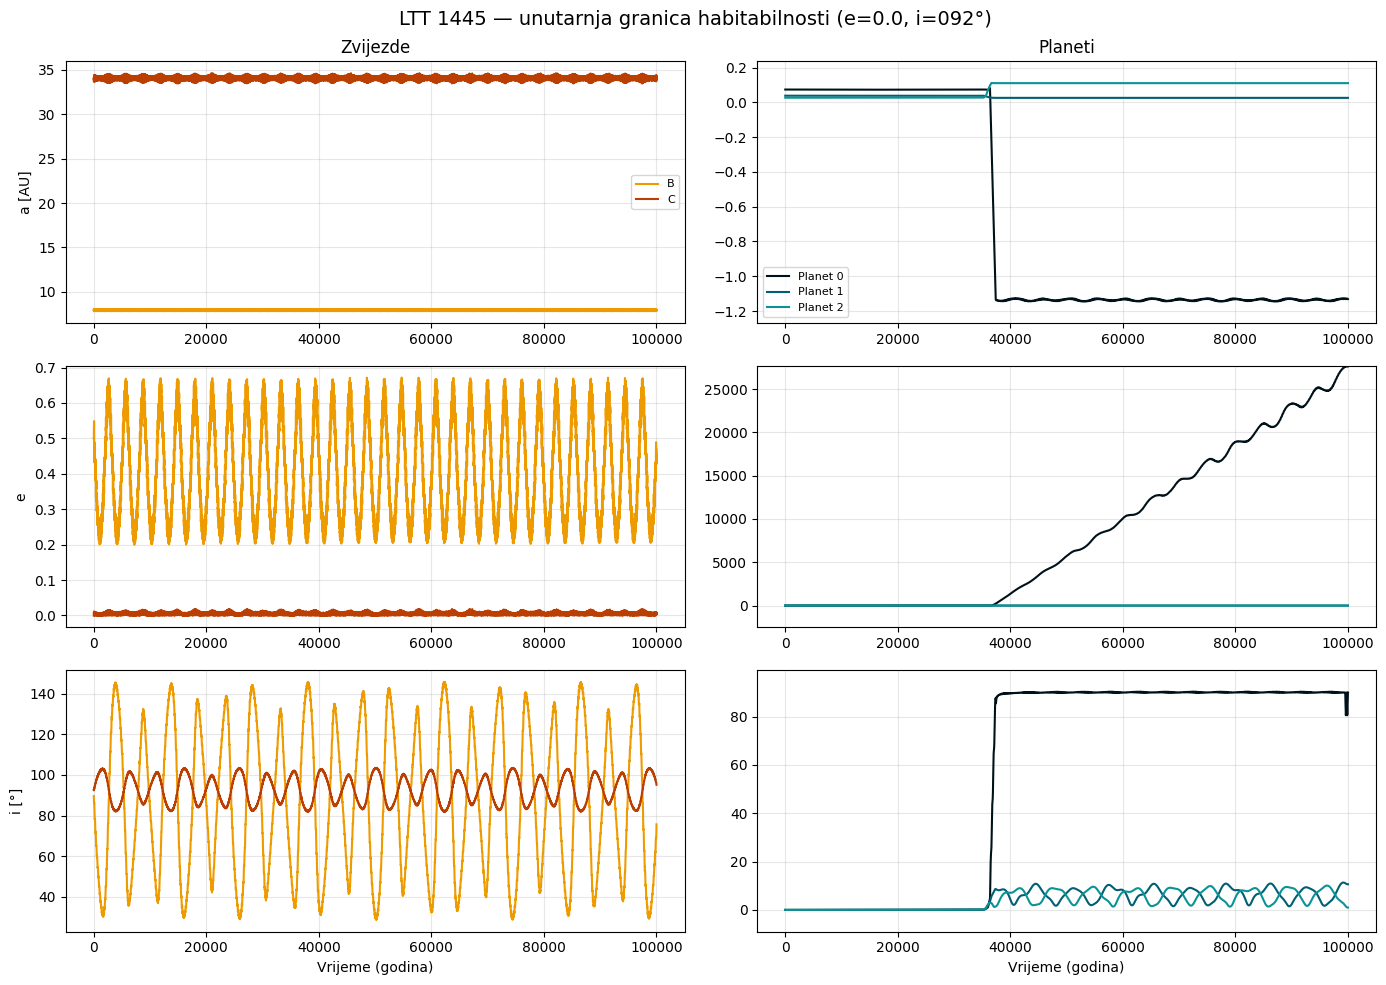

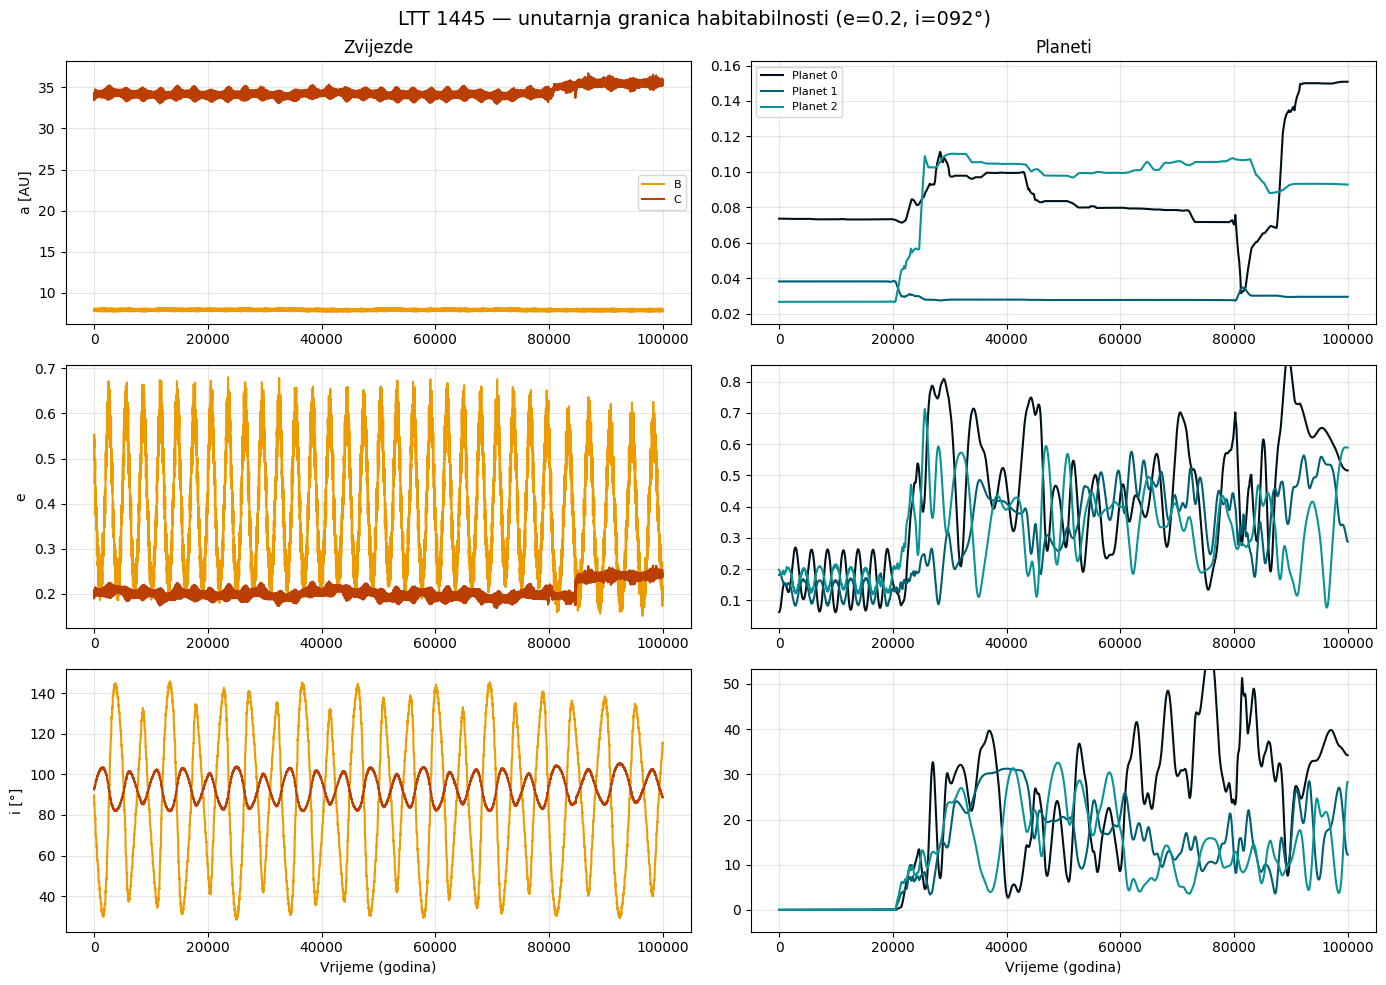

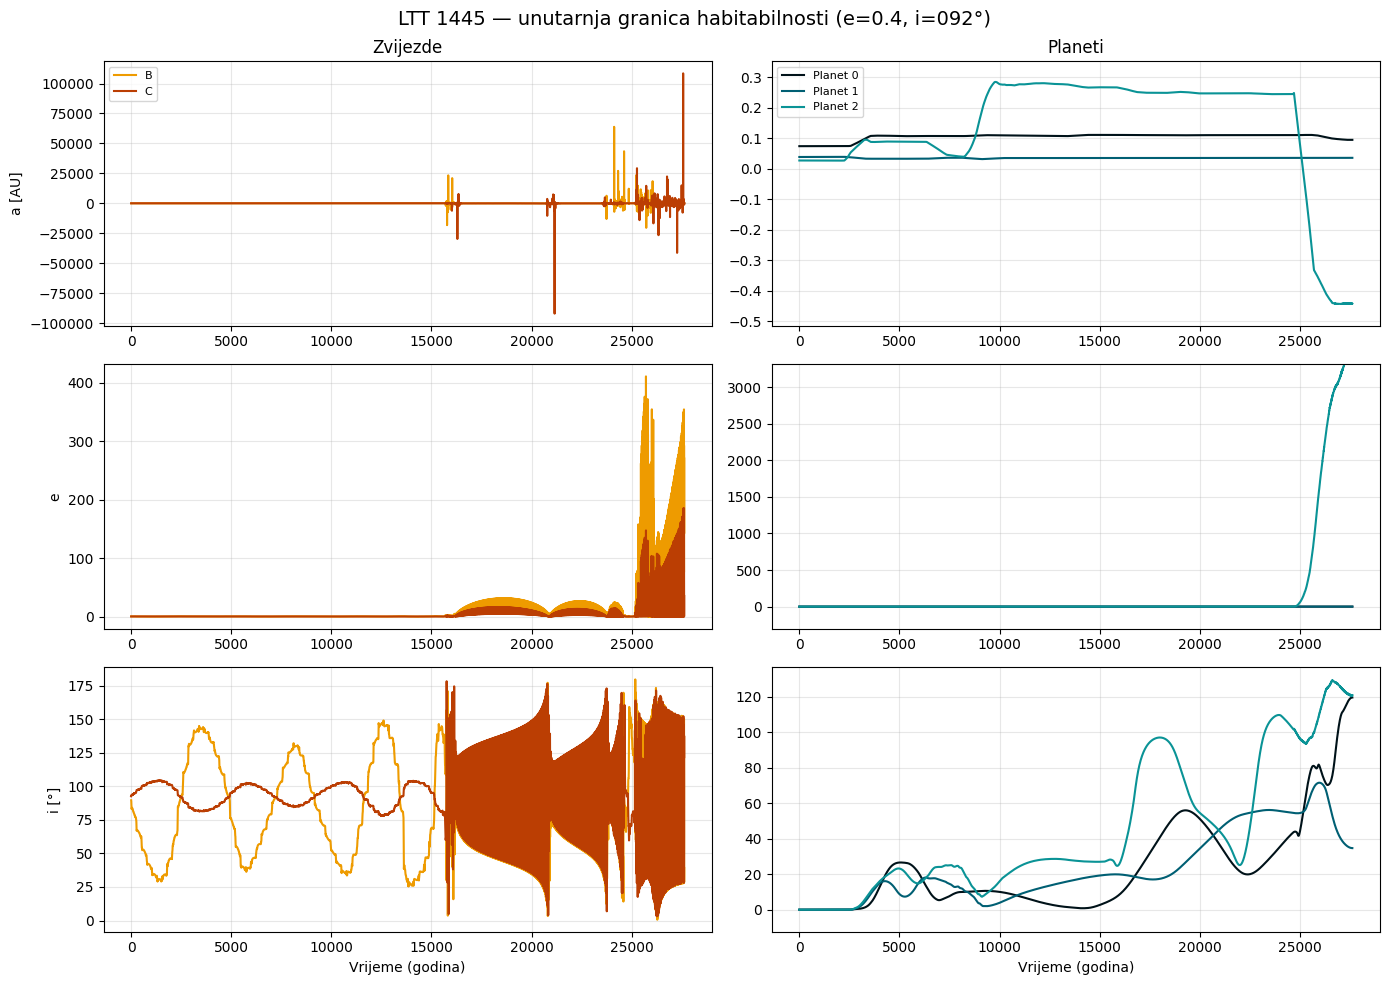

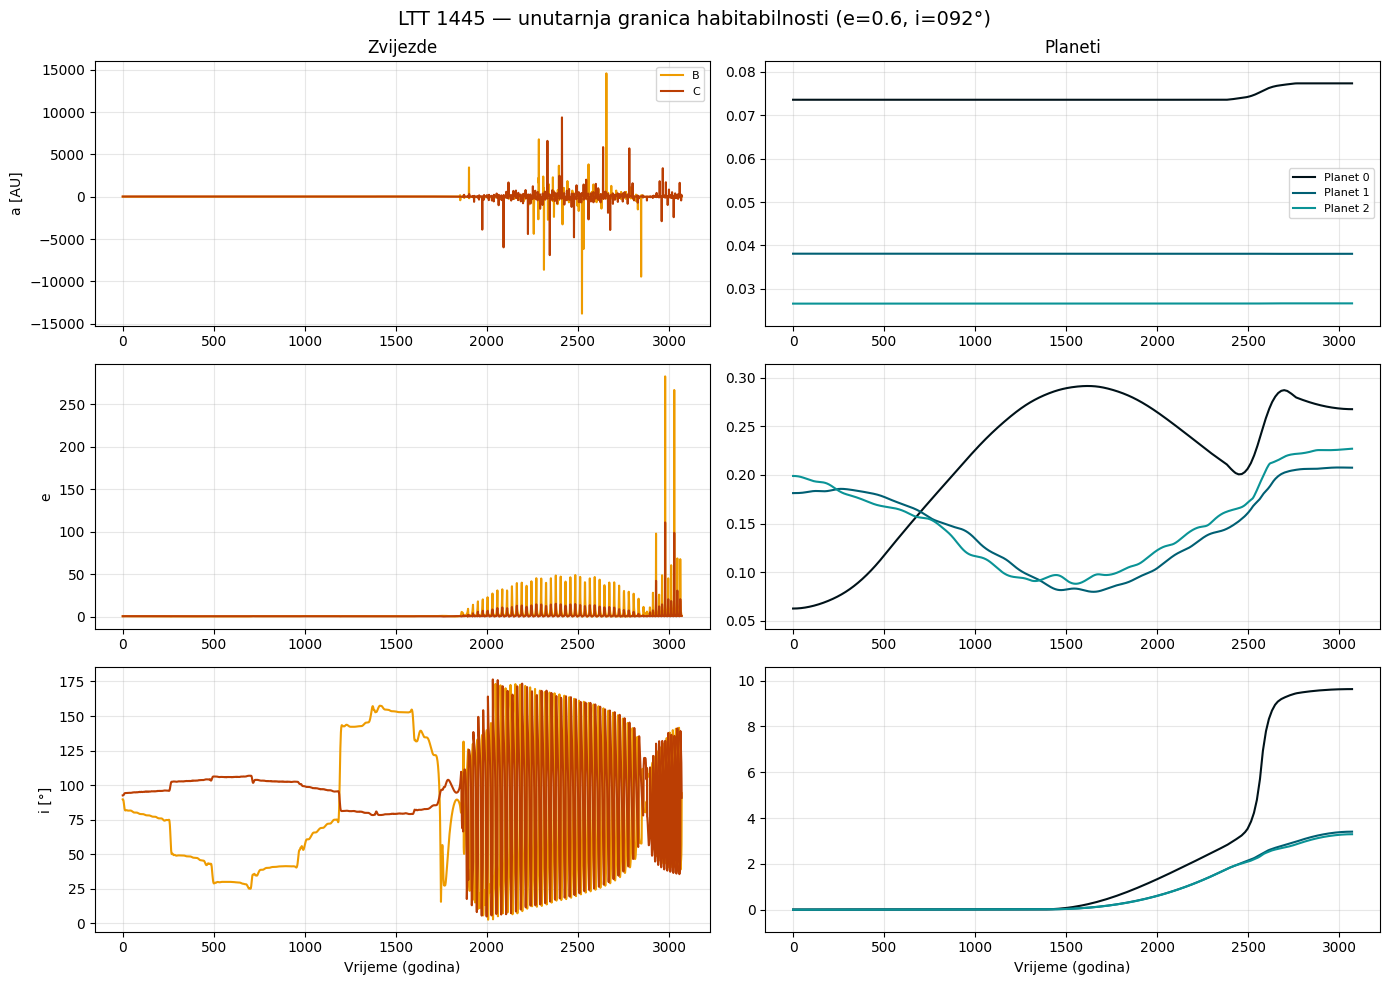

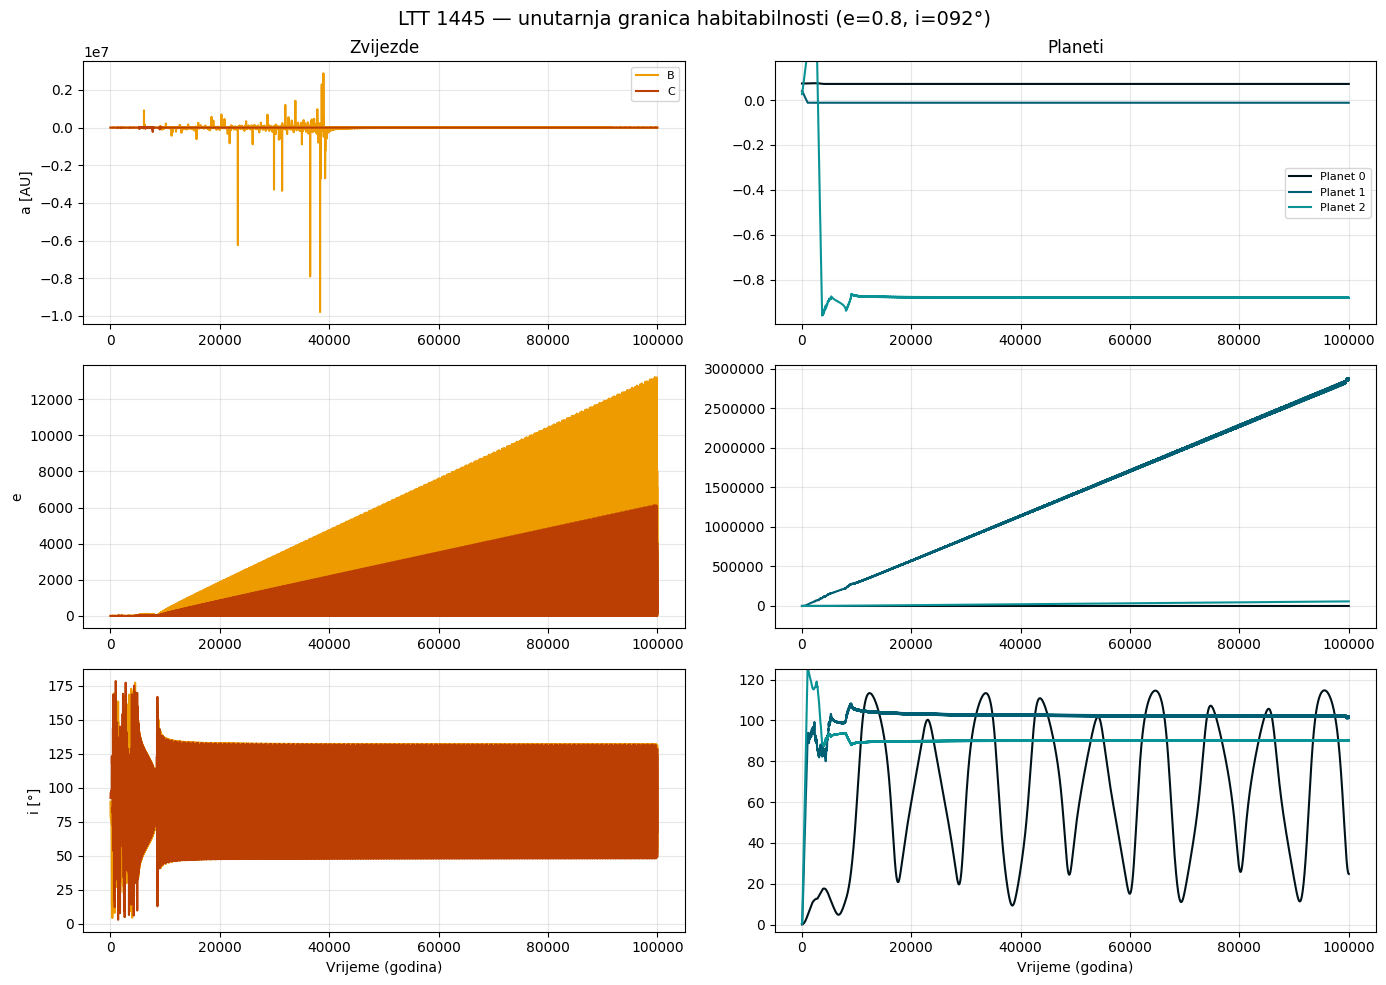

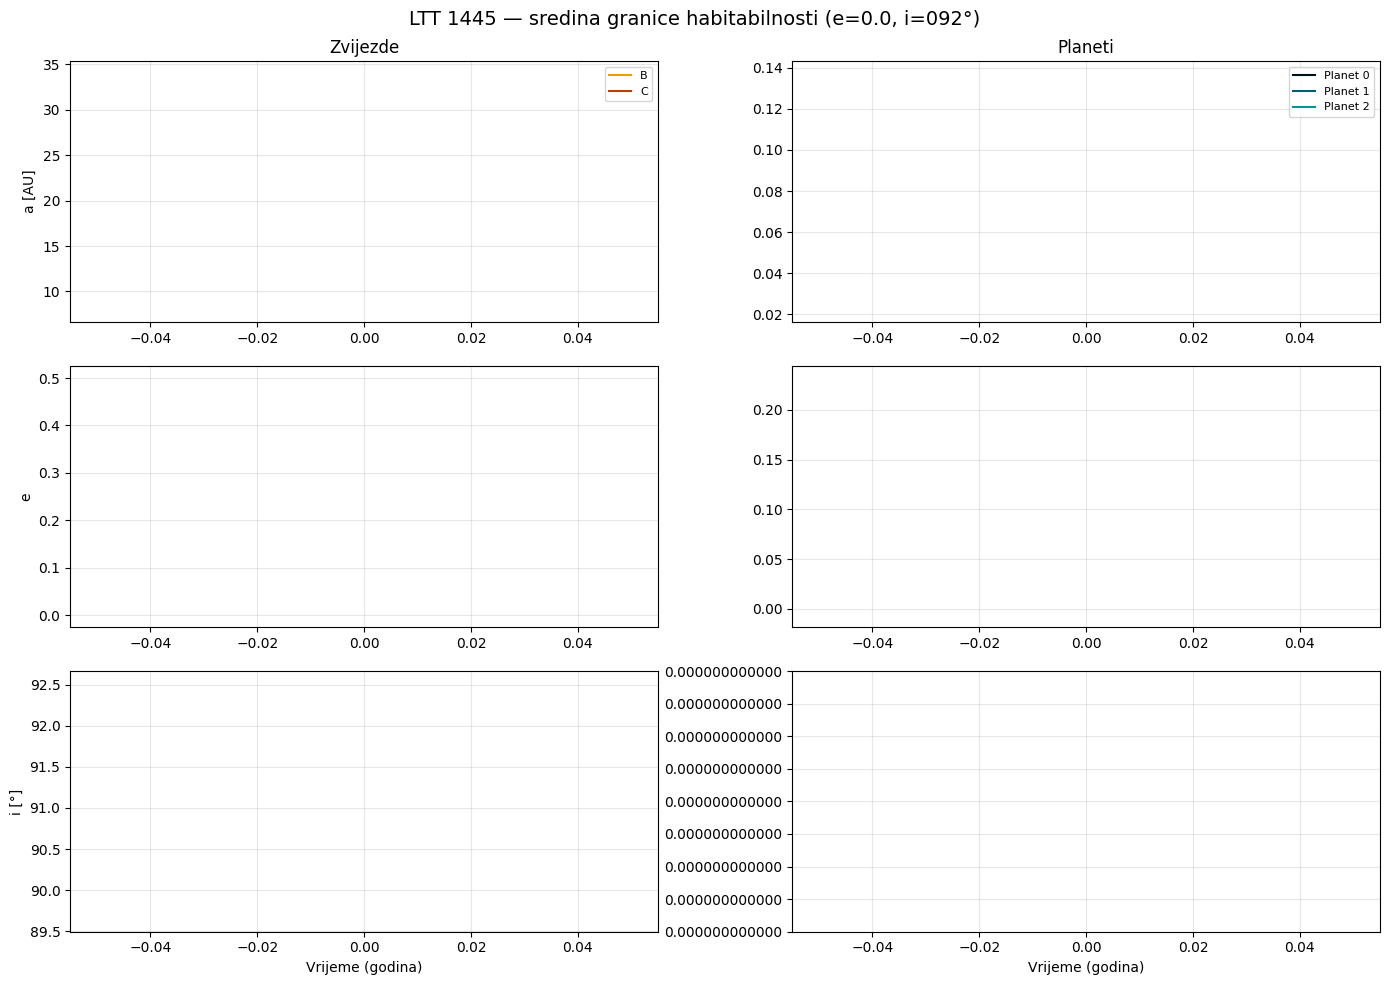

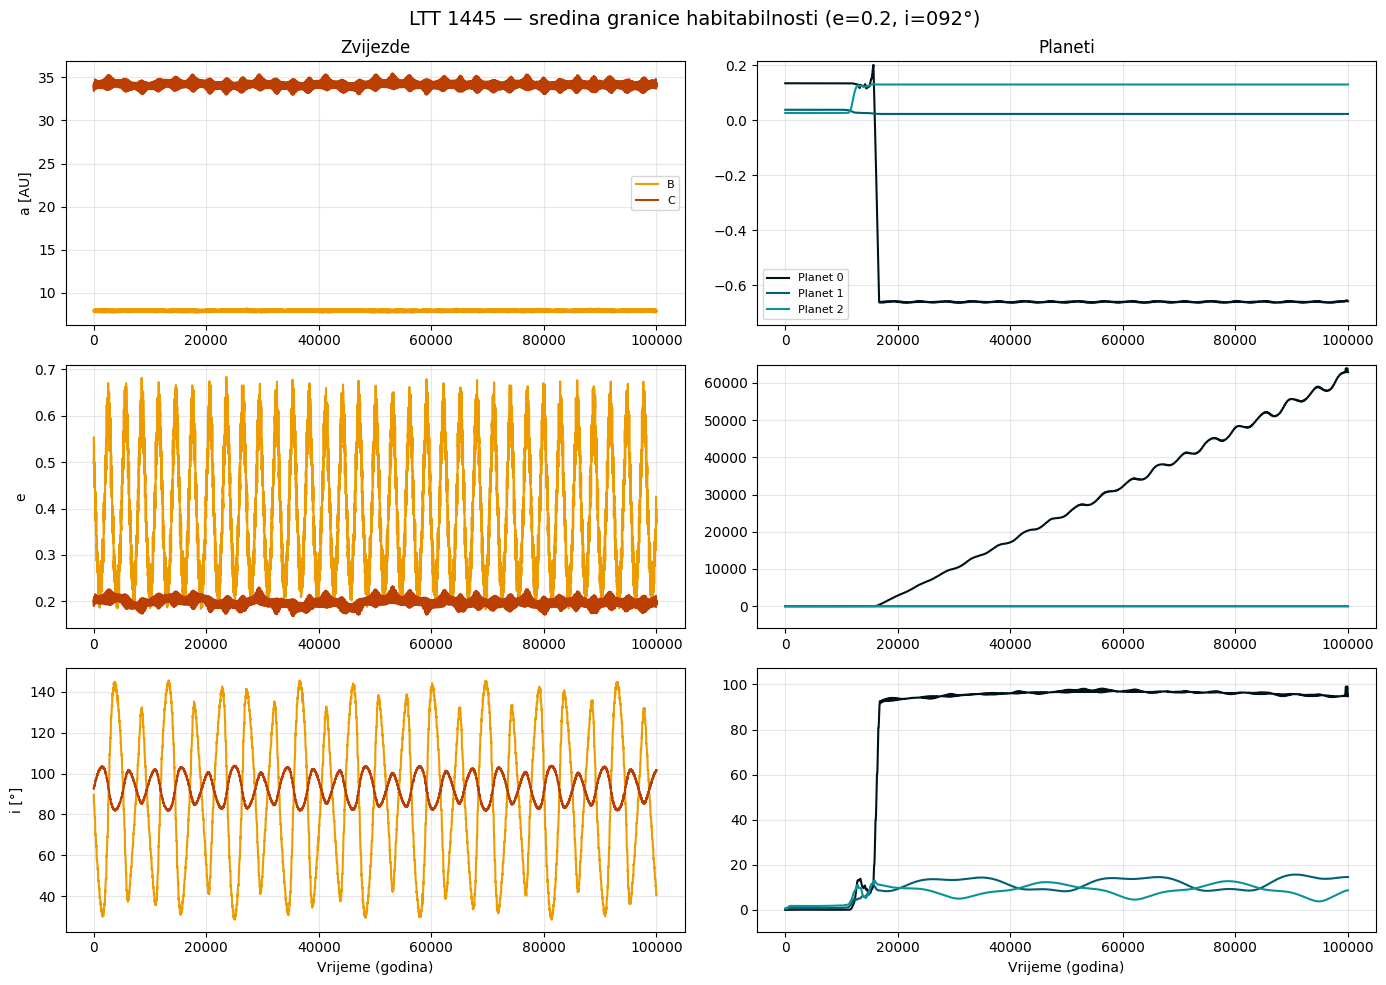

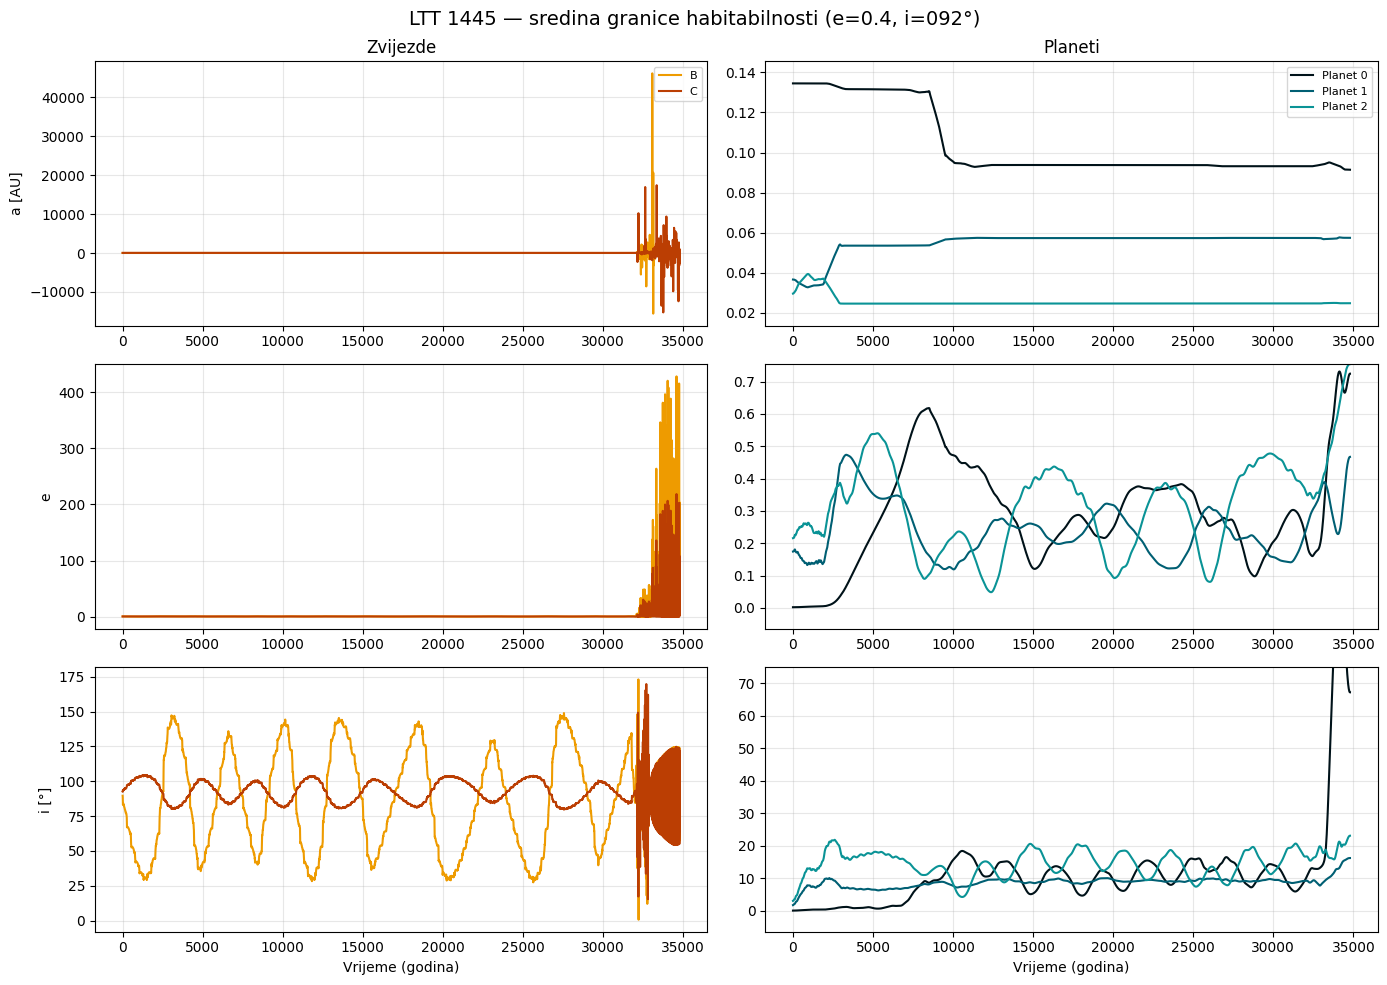

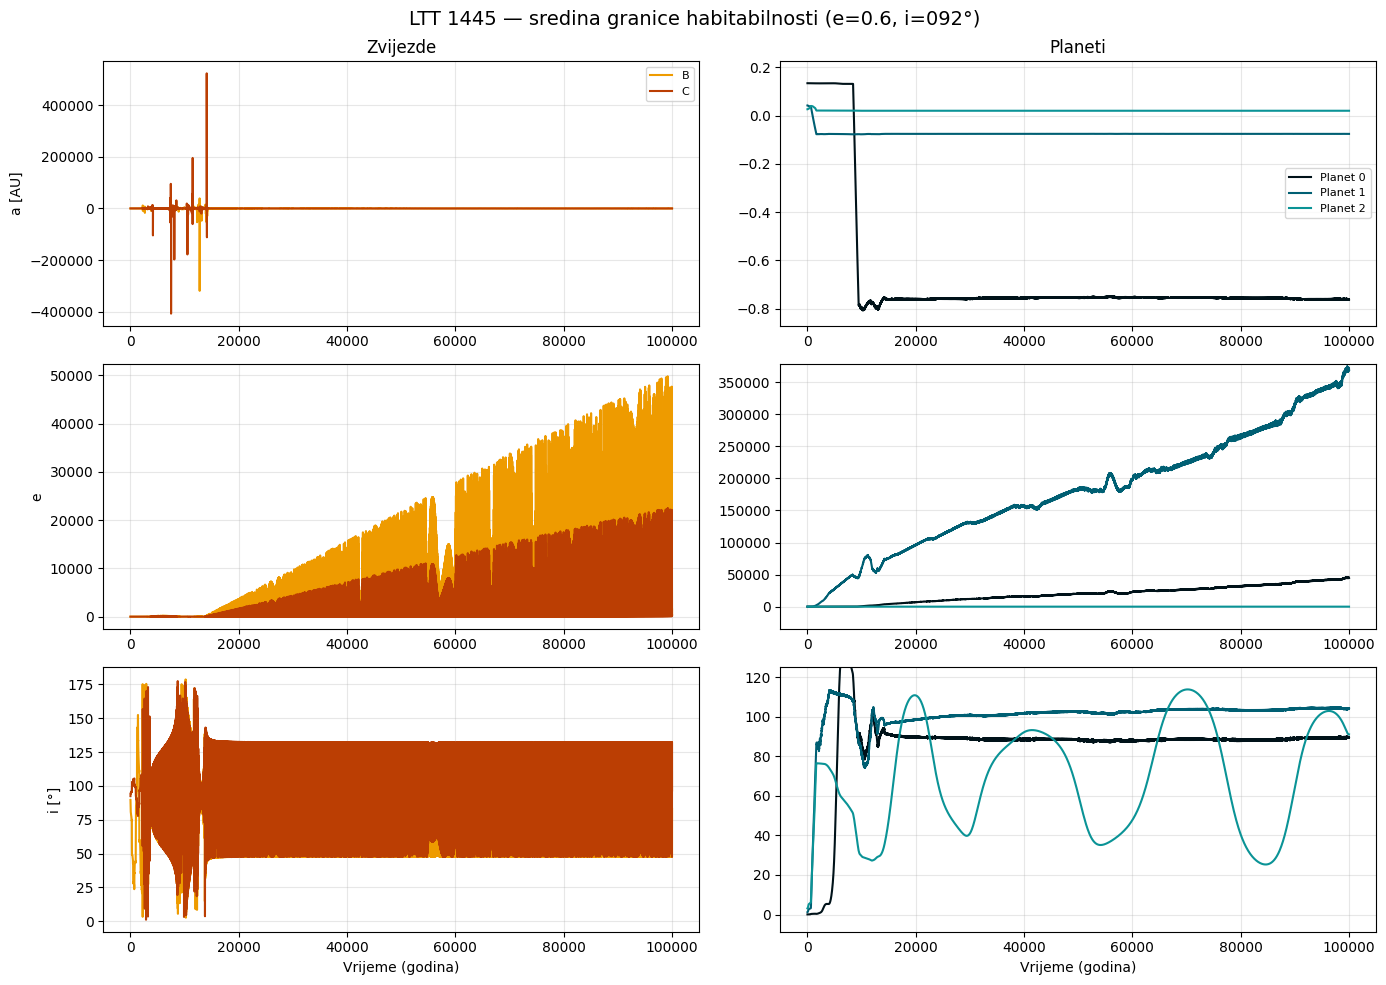

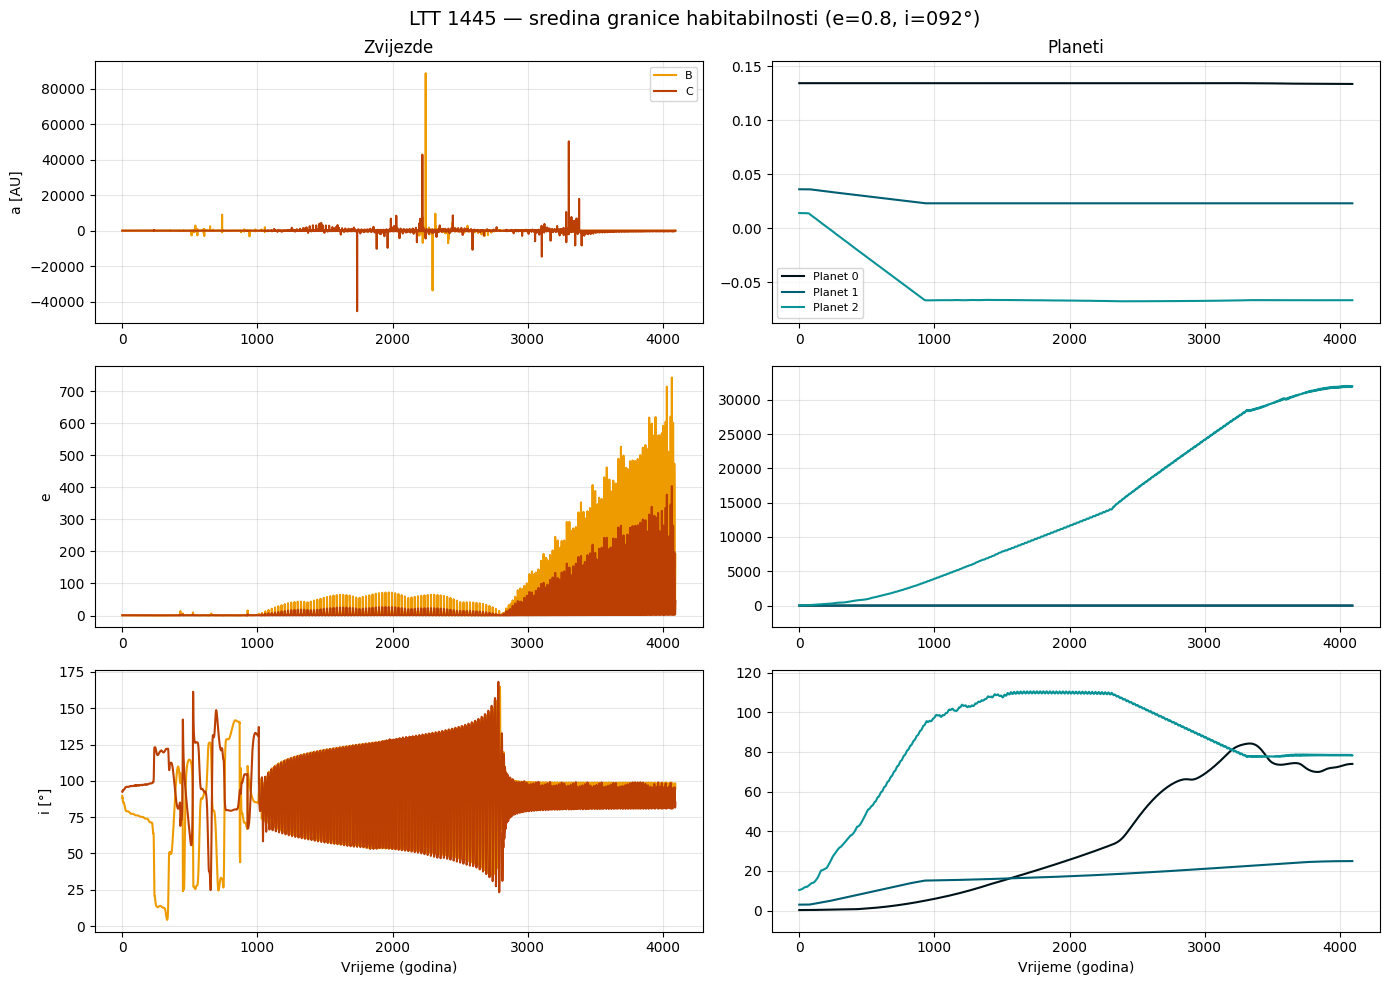

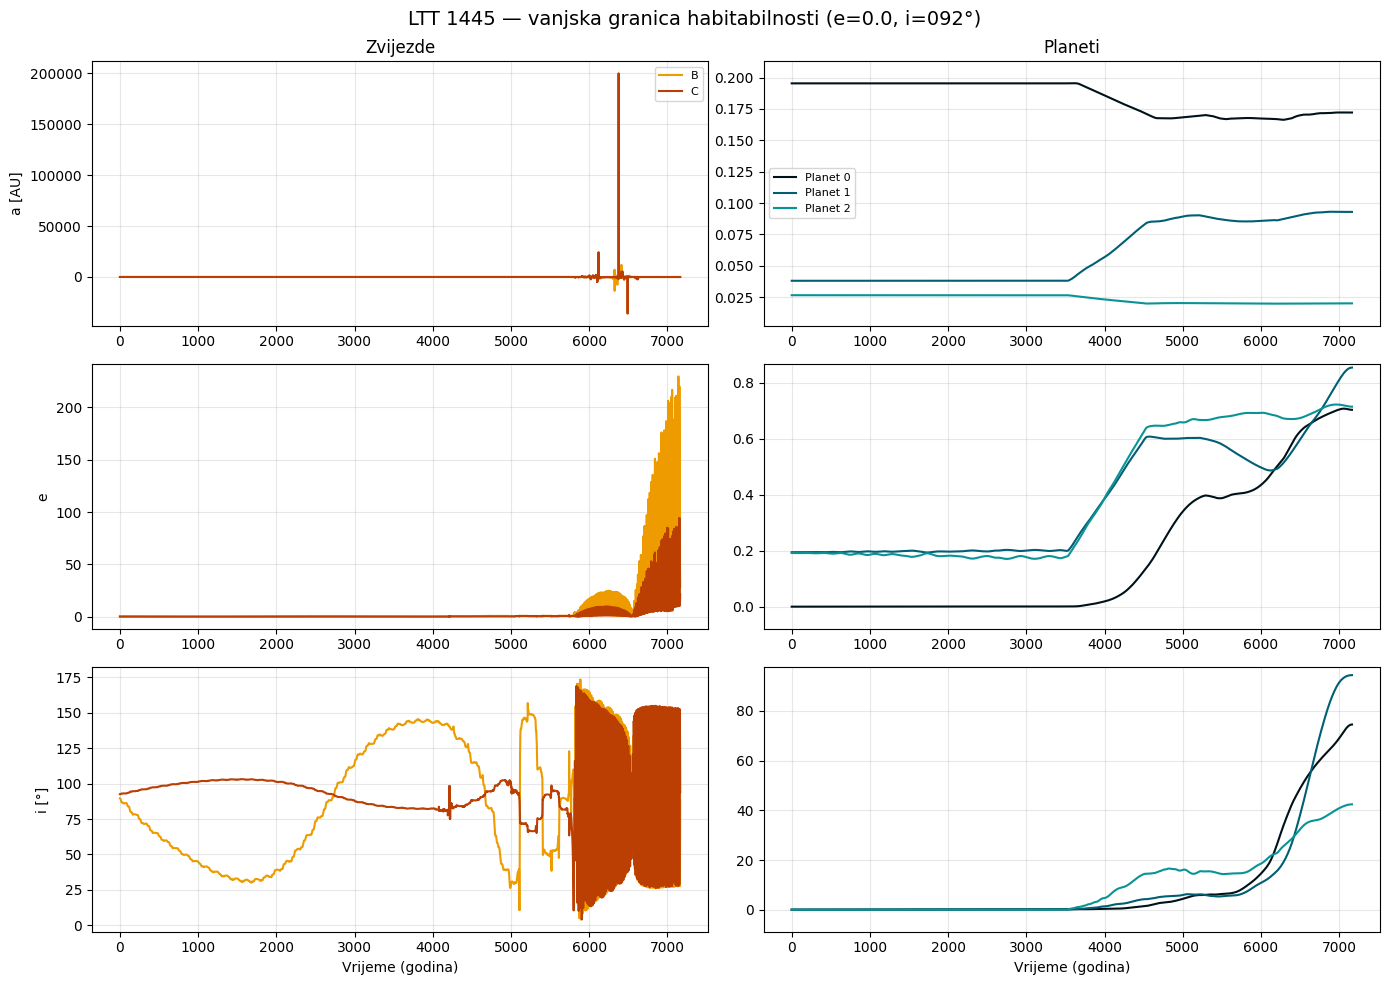

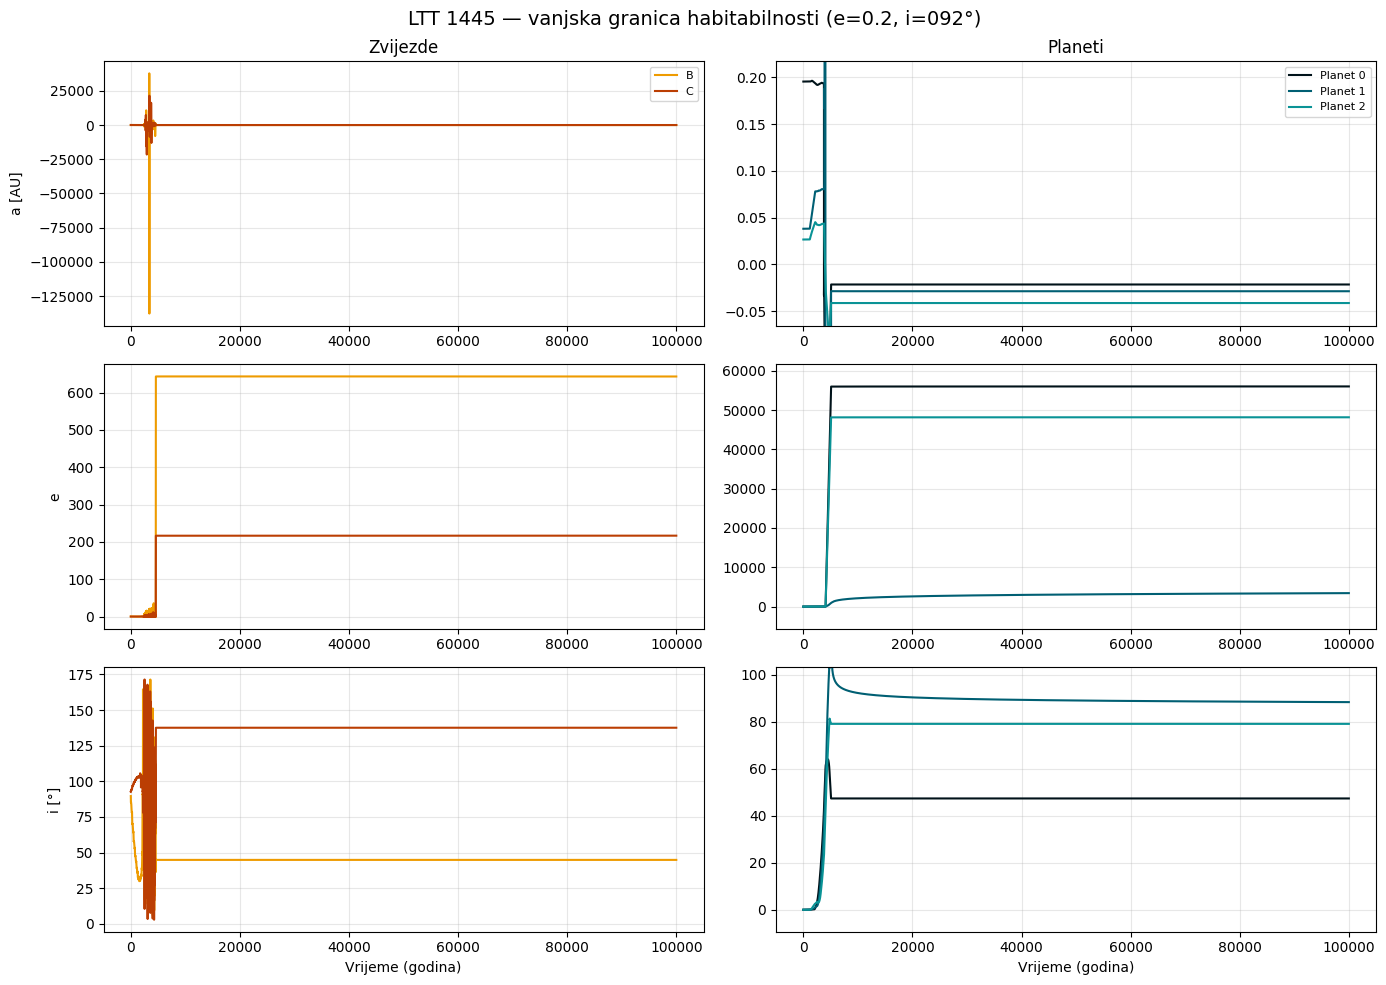

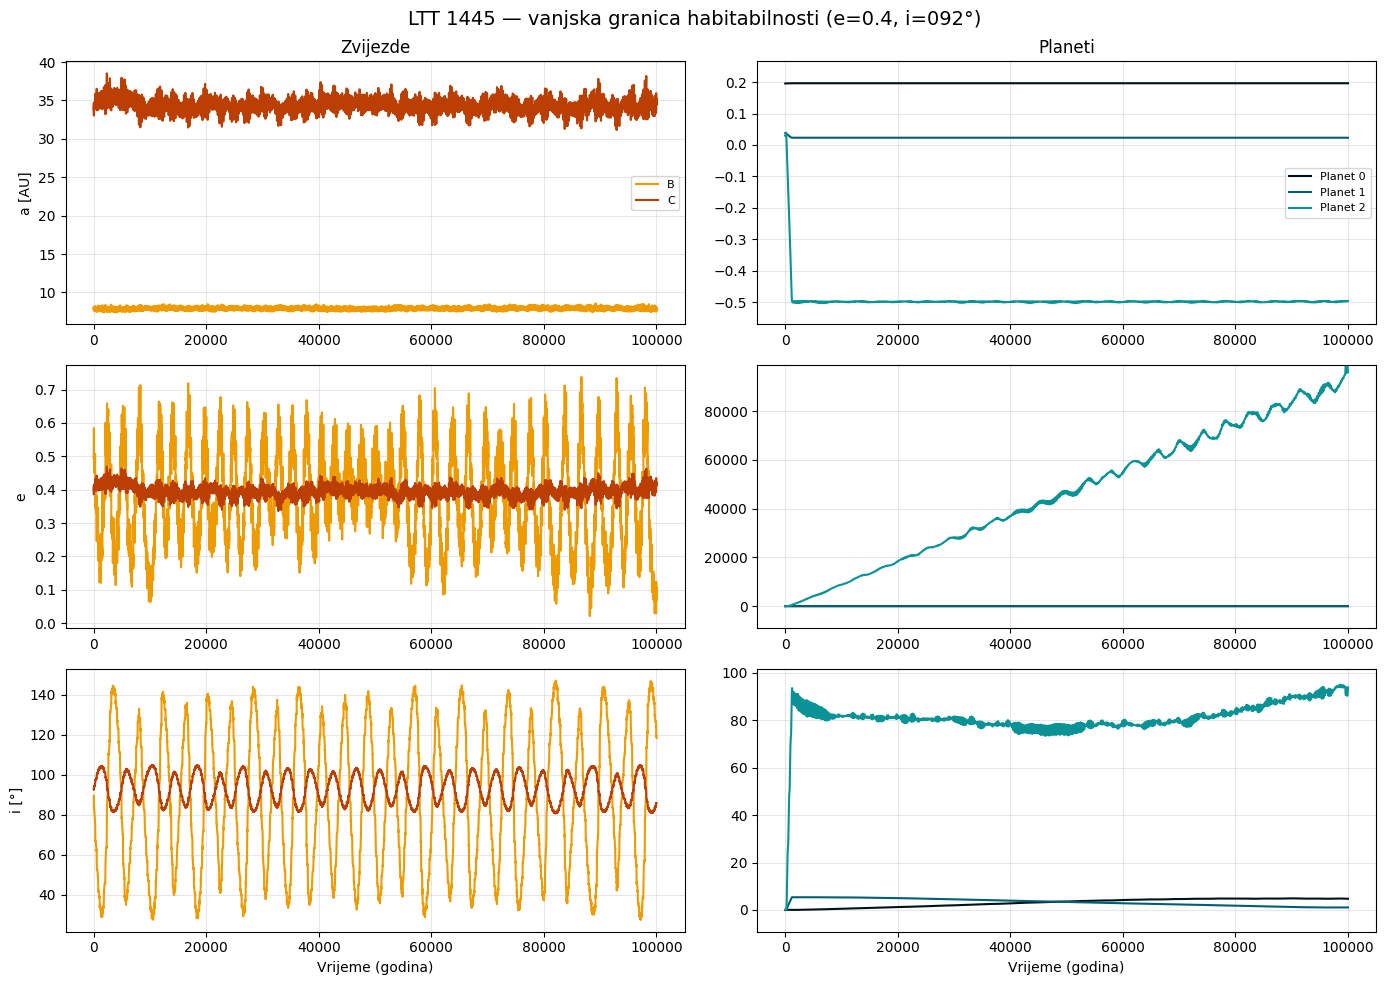

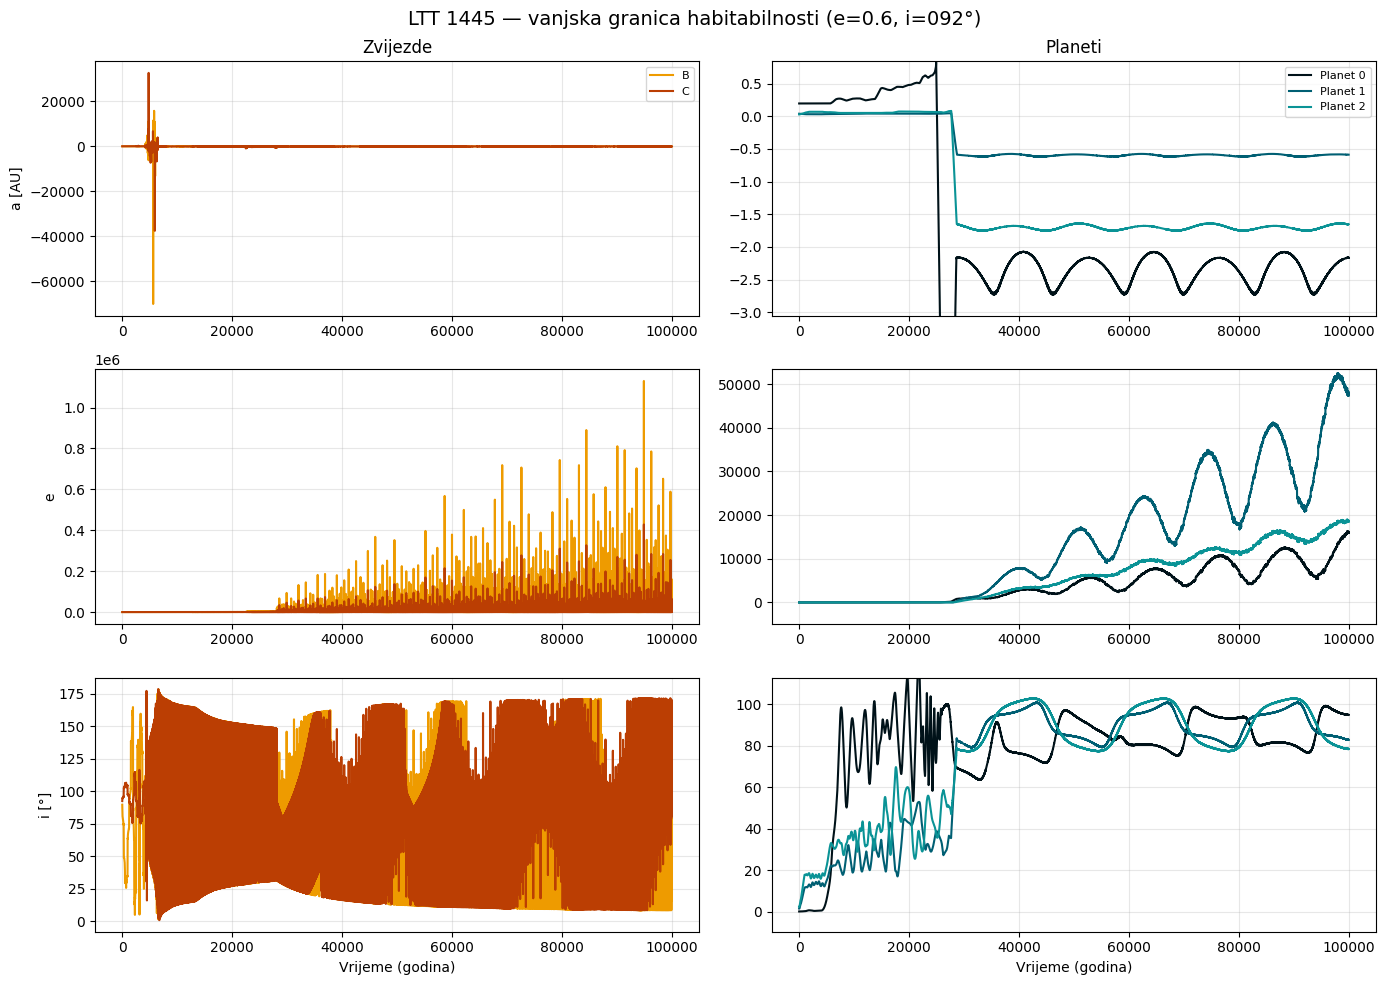

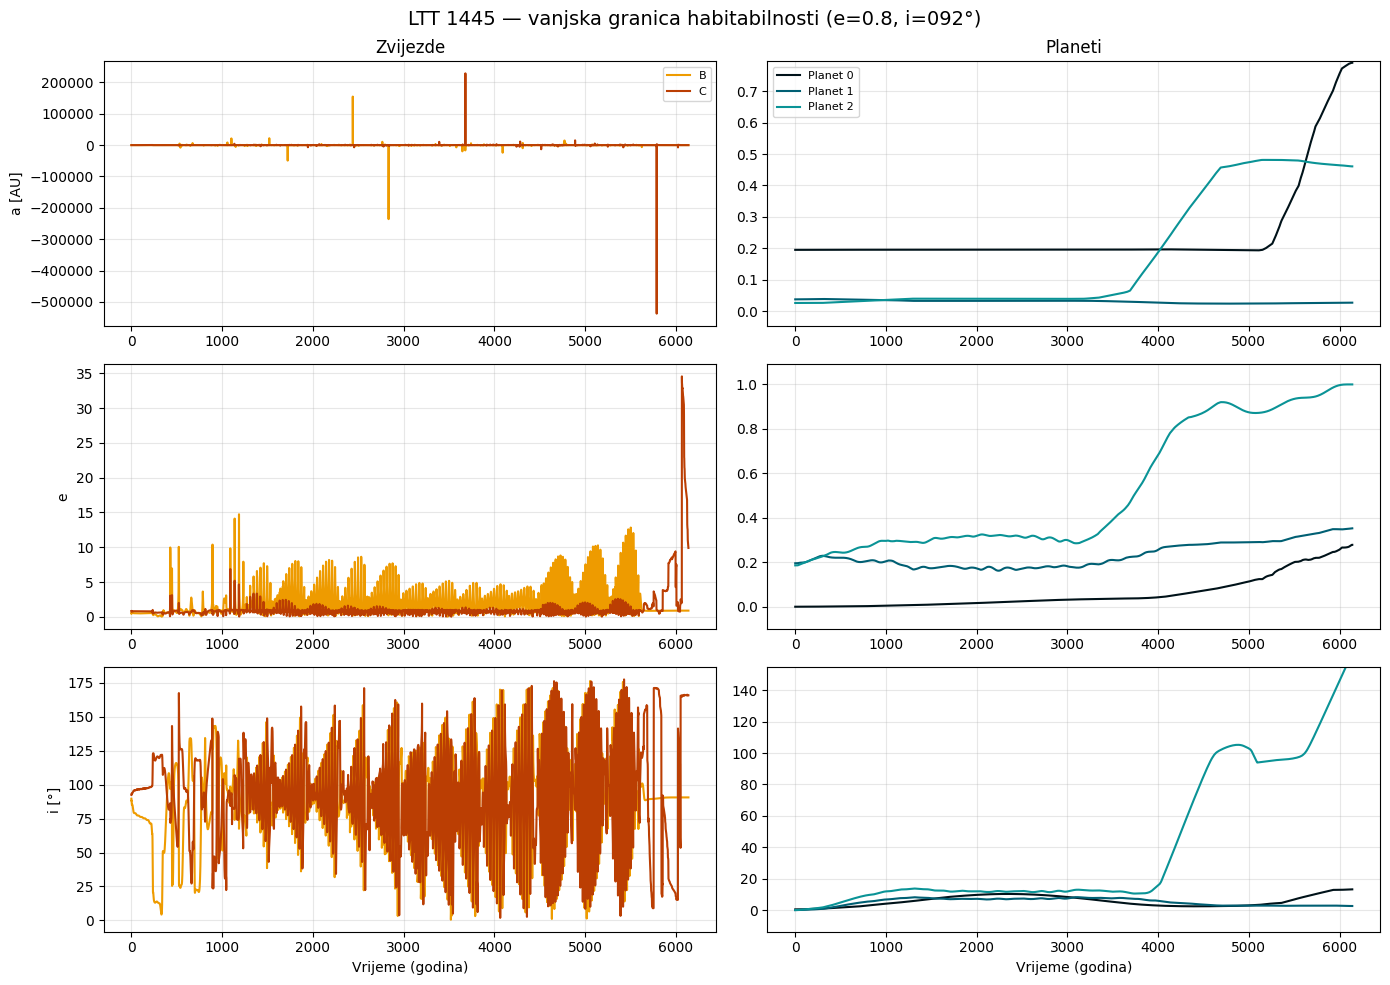

In [8]:
for i, cfg in enumerate(configs):
    path = cfg['output_file']
    if os.path.exists(path) and not os.path.exists('../plots_orbit/'+cfg['experiment_name']+'.png'):
        plot_orbital_elements(path, star_smooth=1, planet_smooth=1000, save=cfg['experiment_name']+'.png')
    else:
        print('skipped', cfg['output_file'])

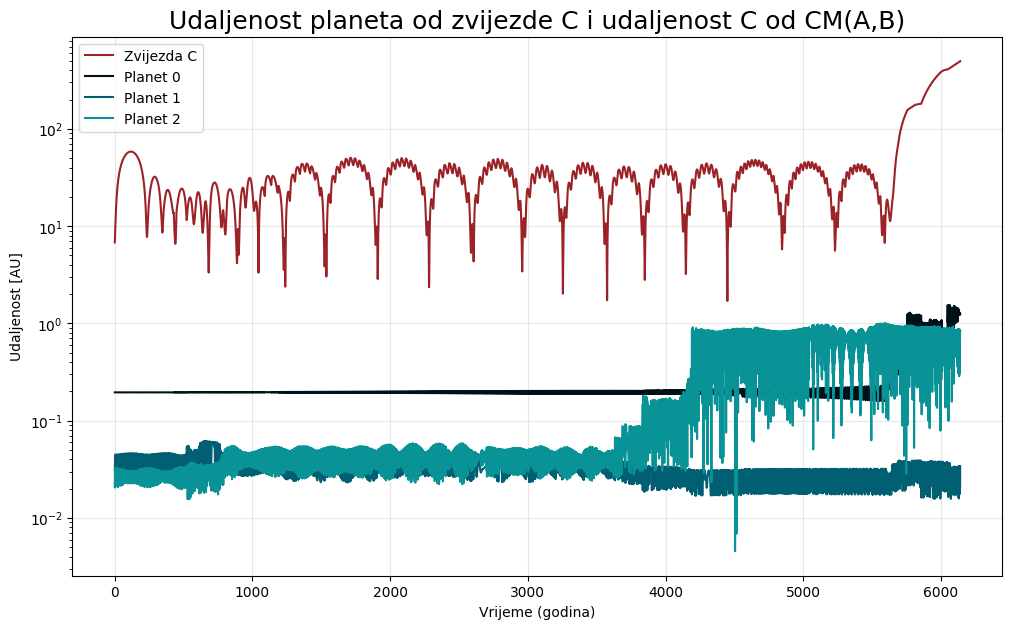

In [24]:
path = '../output/LTT_1445_hz_outer_ev0.8_iv092.hdf5'

t, pos, mass, ptype, hz_inner_radius, hz_outer_radius, energy, temperature, in_hz, a, e, inc, s_eff_inner, s_eff_outer = load_hdf5_data(path)
star_idx, planet_idx, iA, iB, iC, mA, mB, r_com_bin = determine_system(mass, pos, ptype)
planet_colors = ['#001219', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6', '#bb3e03', '#ae2012']

plt.figure(figsize=(12, 7))
plt.title('Udaljenost planeta od zvijezde C i udaljenost C od CM(A,B)', fontsize=18)
d = np.linalg.norm(pos[:, 2, :] - r_com_bin, axis=1)
plt.plot(t, d, label='Zvijezda C', color='#9B2226')

for pi in planet_idx:
    d = np.linalg.norm(pos[:, pi, :] - pos[:, 2, :], axis=1)
    plt.plot(t, d, label=f'Planet {pi-3}', color=planet_colors[(pi-3) % len(planet_colors)])
plt.yscale('log')
plt.xlabel('Vrijeme (godina)')
plt.ylabel('Udaljenost [AU]')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../plots_unstable/'+'LTT_1445_hz_outer_ev0.8_iv092.png', dpi=300)
plt.show()


skipped ../output/Gliese_667_observed_ev0.0_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.0_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.0_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.0_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.2_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.4_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv030.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv060.hdf5
skipped ../output/Gliese_667_observed_ev0.6_iv090.hdf5
skipped ../output/Gliese_667_observed_ev0.8_iv000.hdf5
skipped ../output/Gliese_667_observed_ev0.8_iv030.hdf5
skipped ..

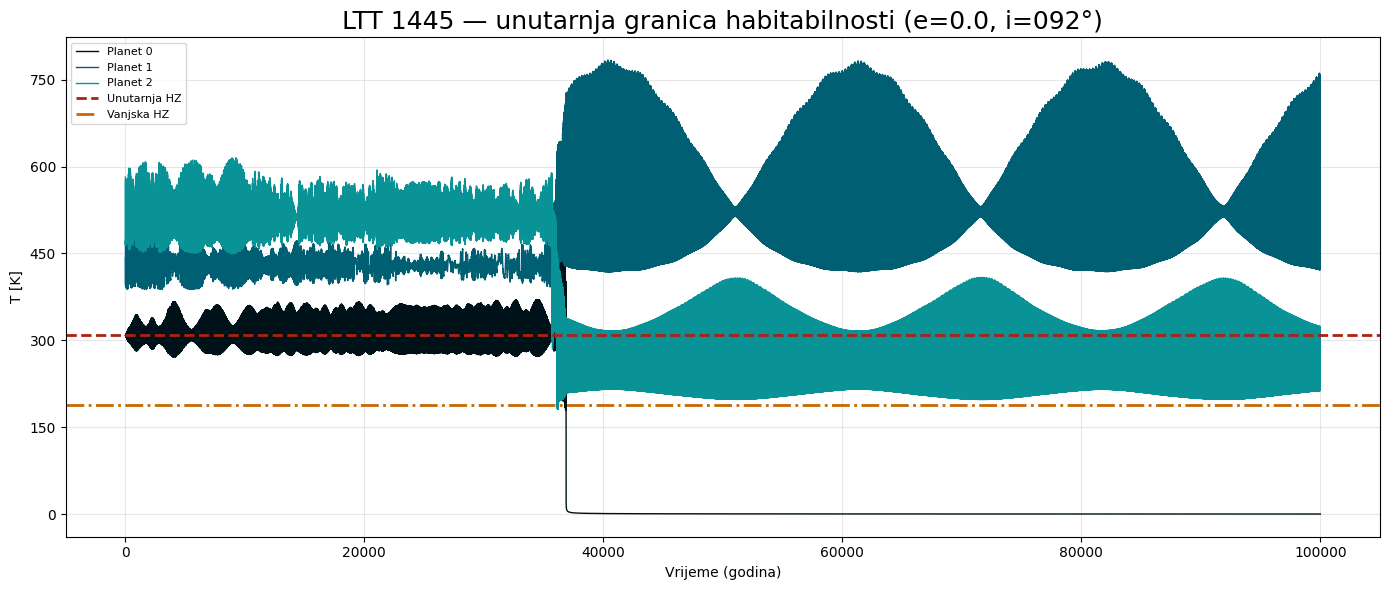

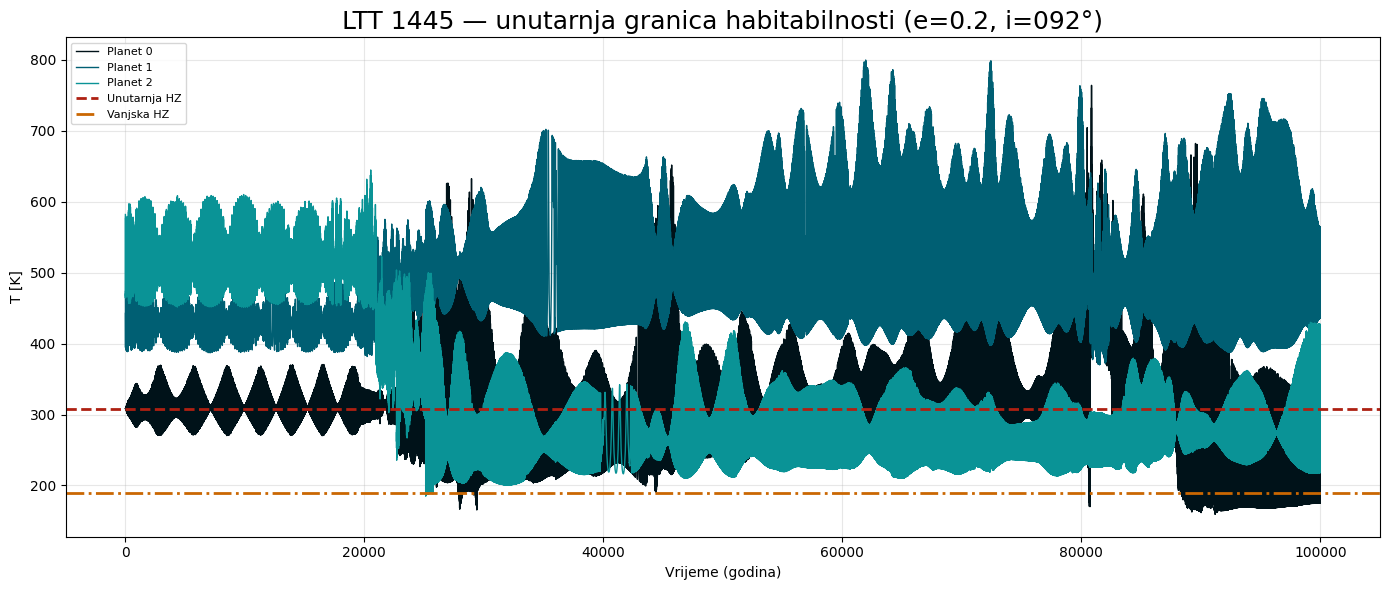

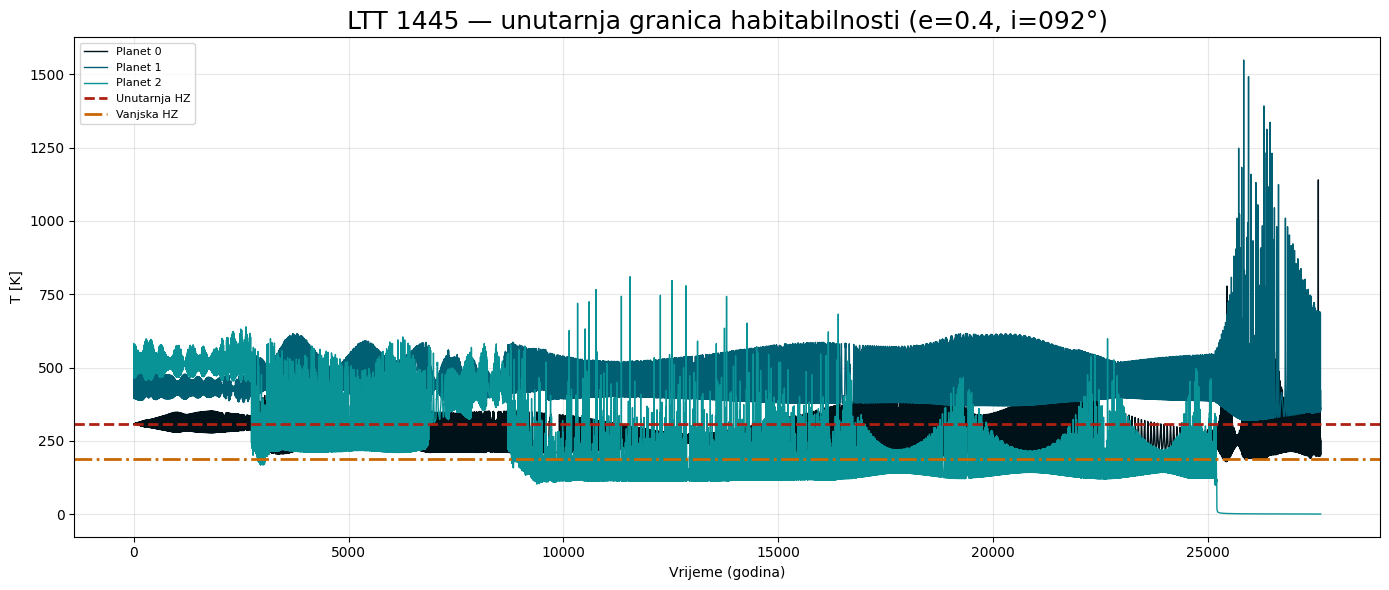

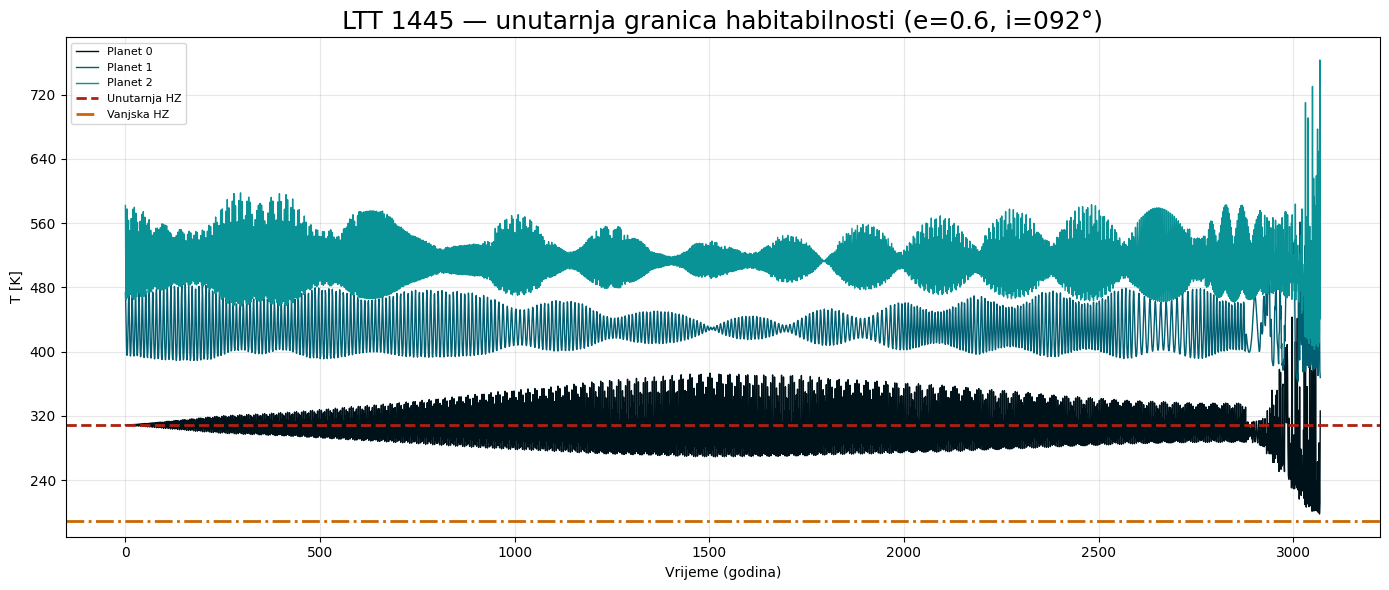

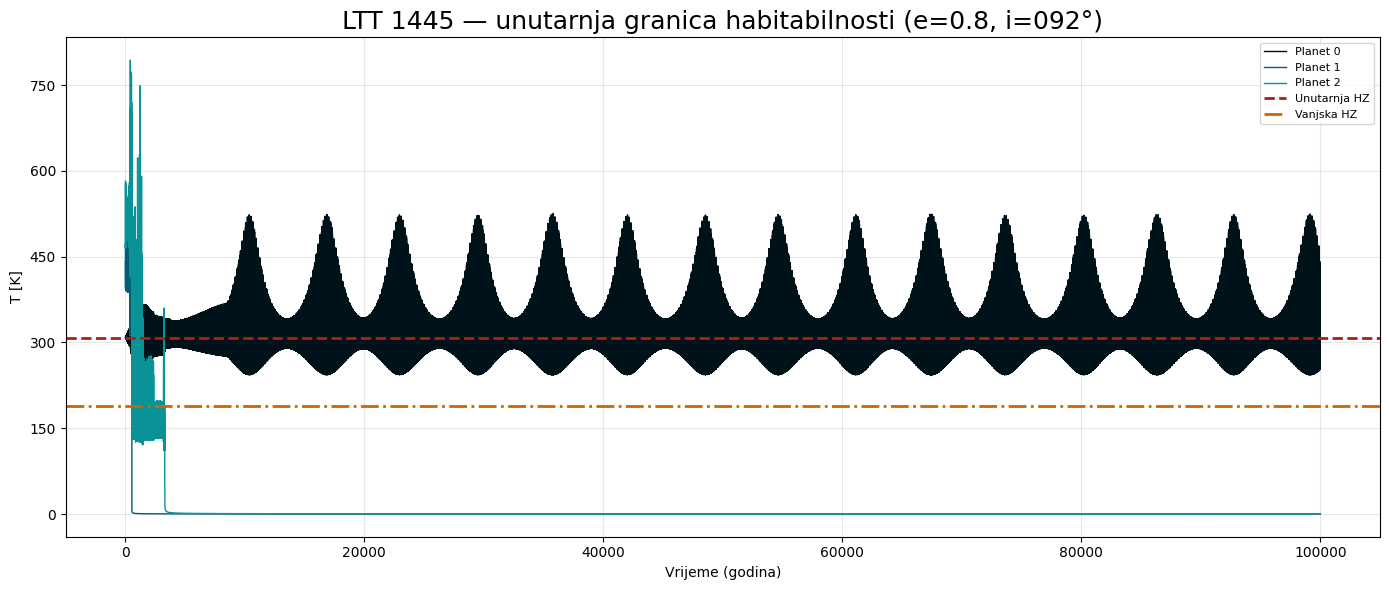

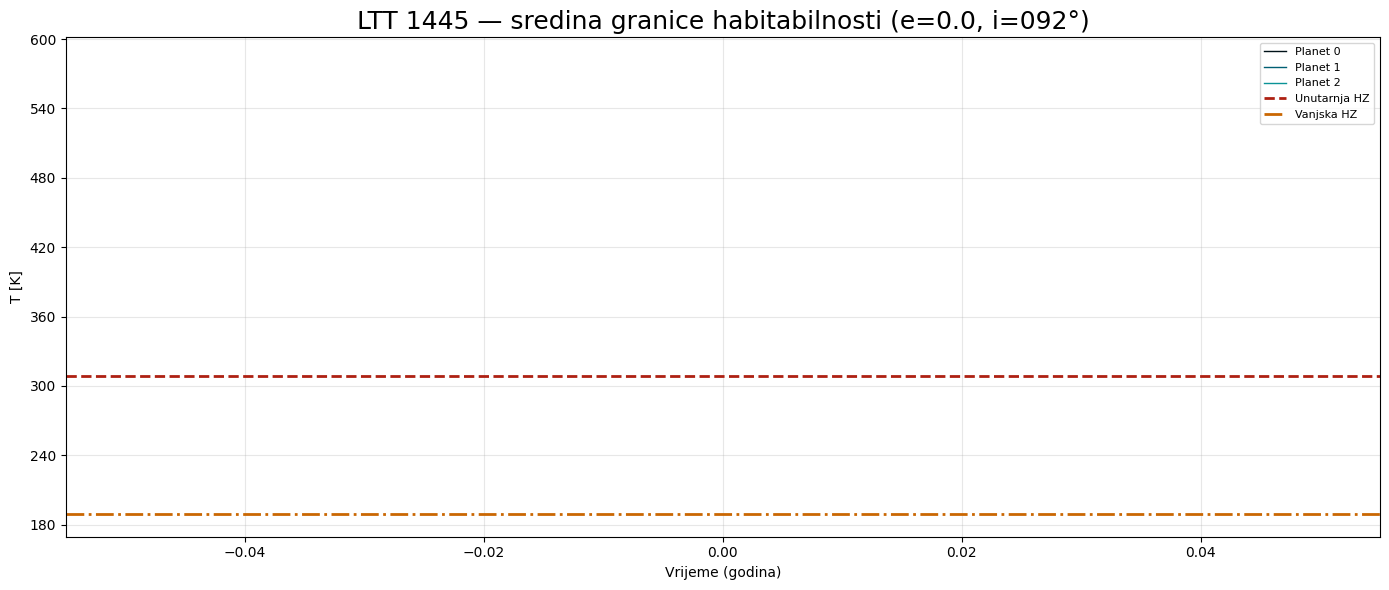

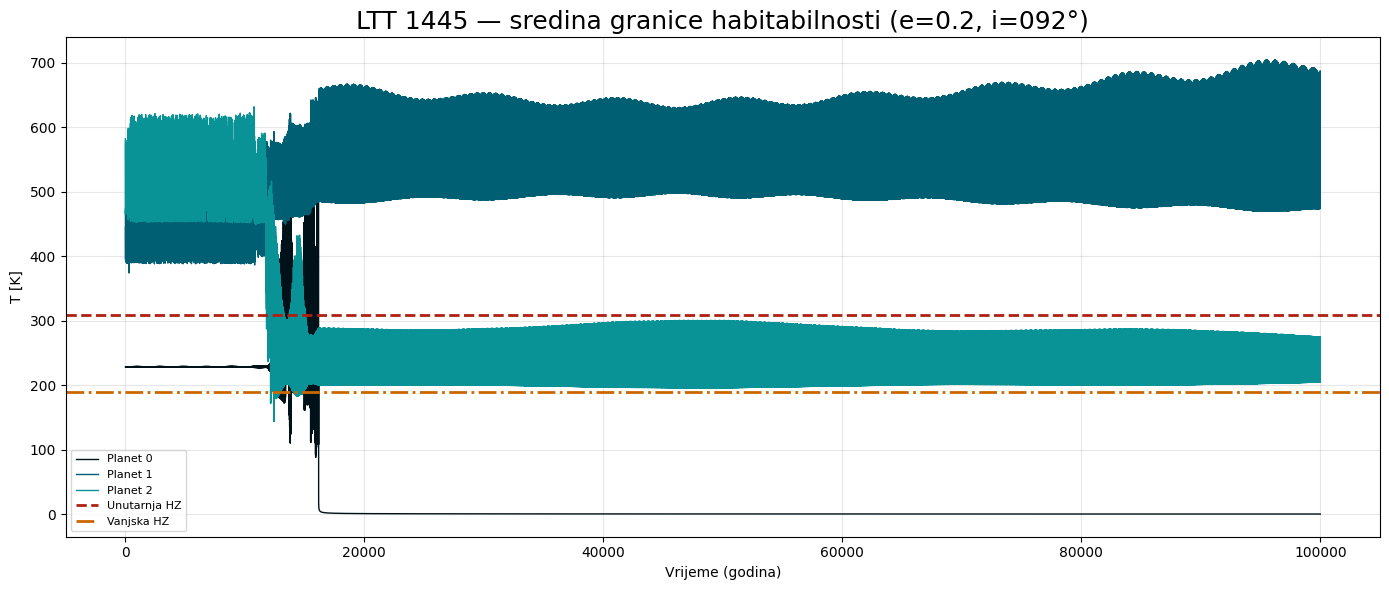

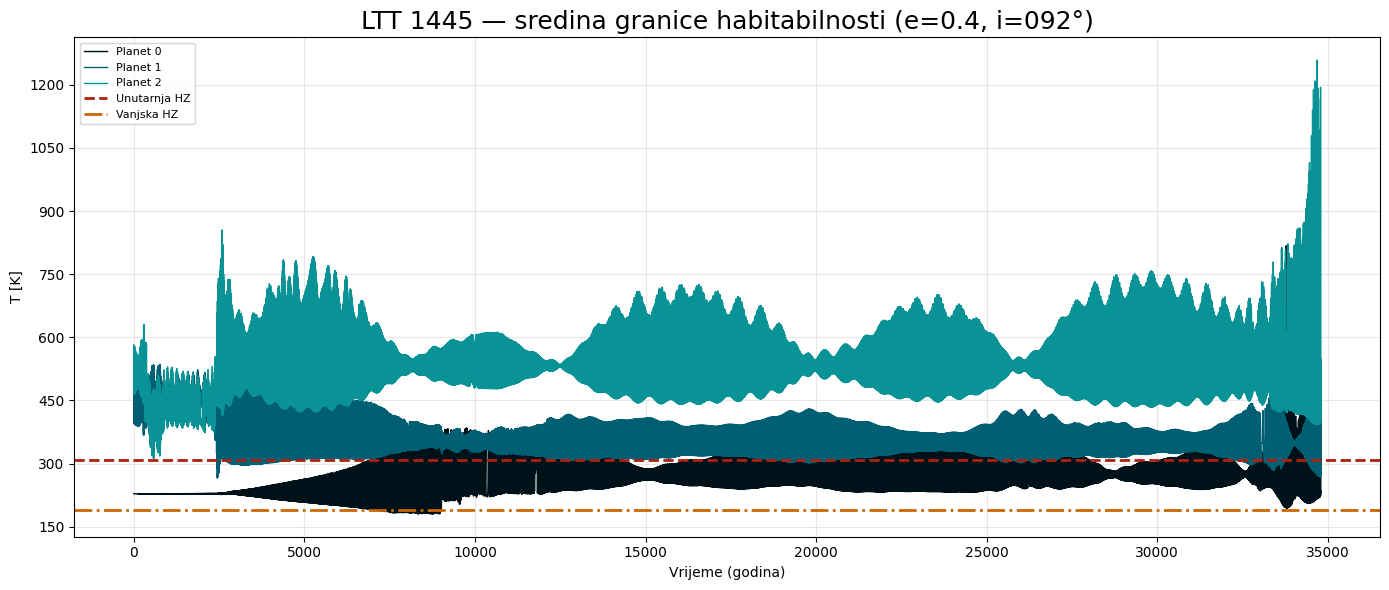

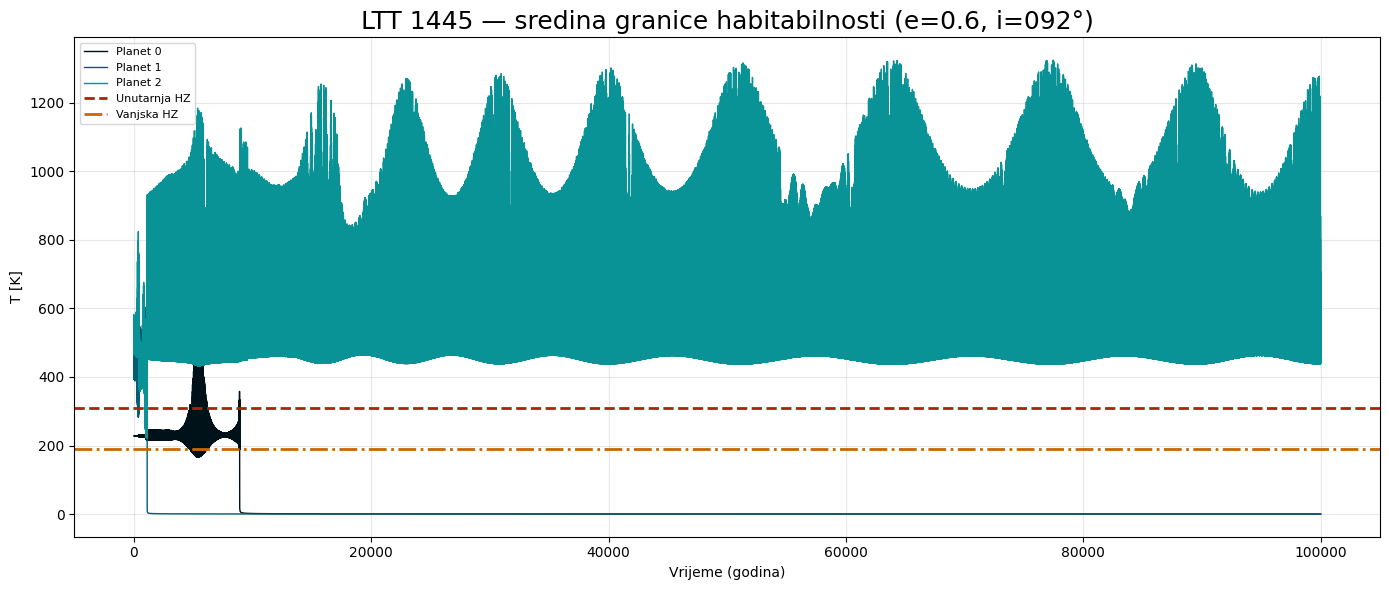

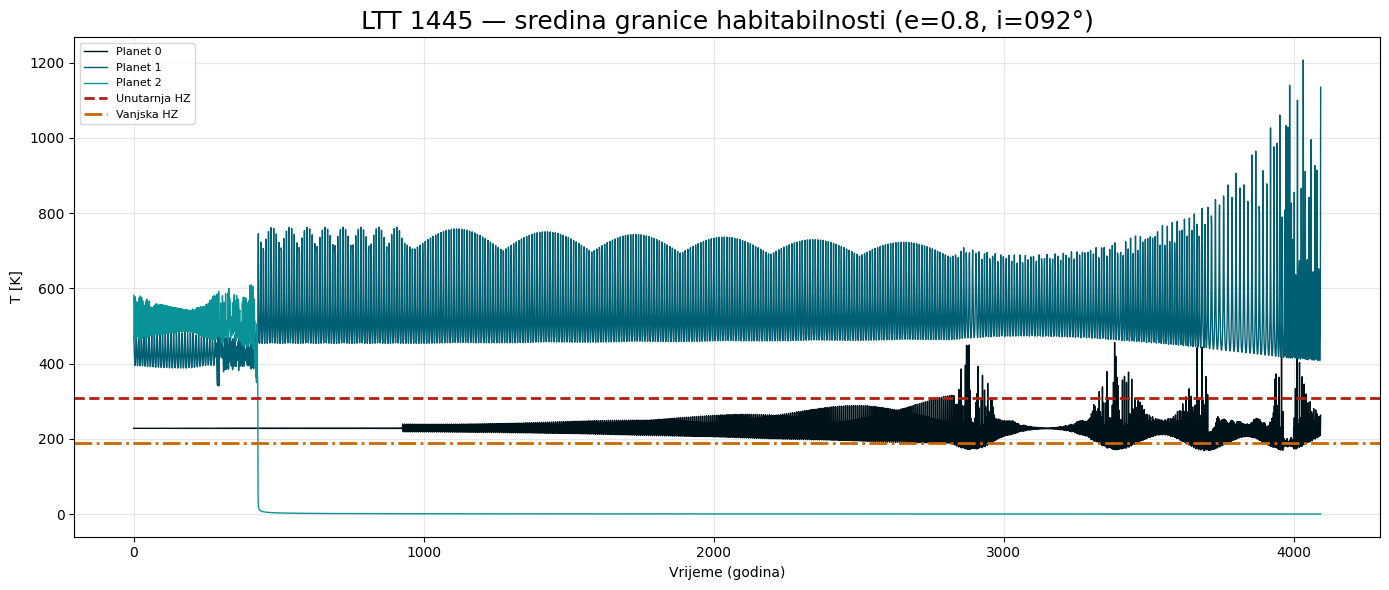

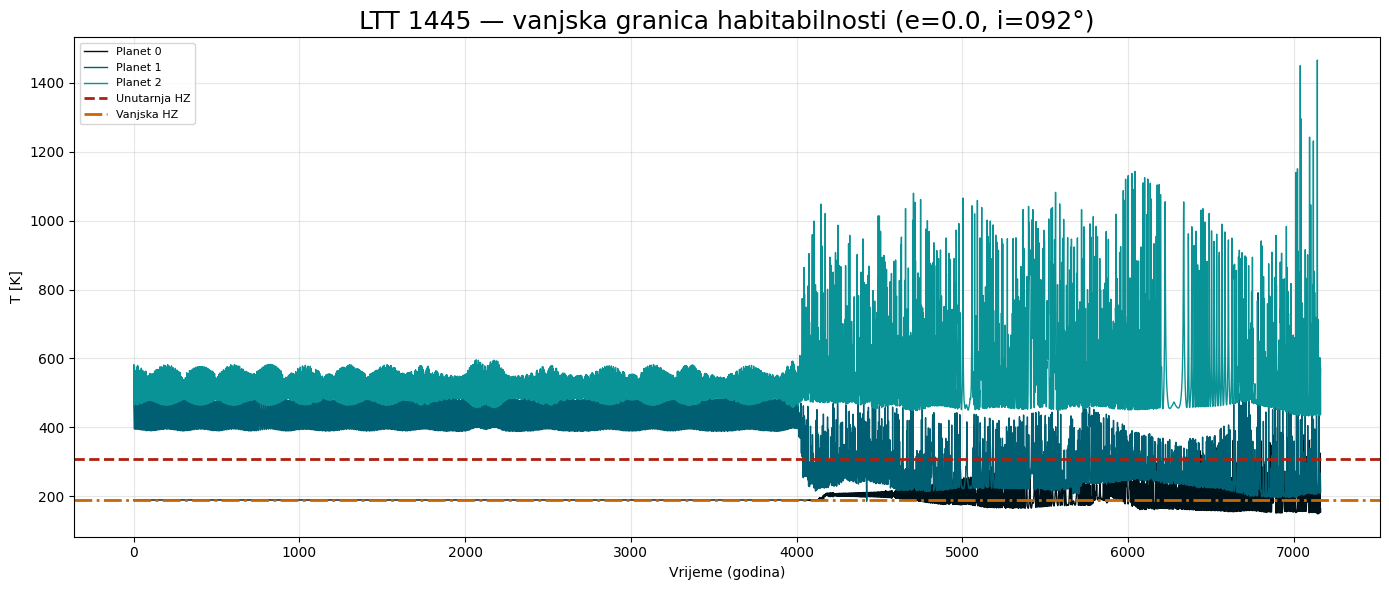

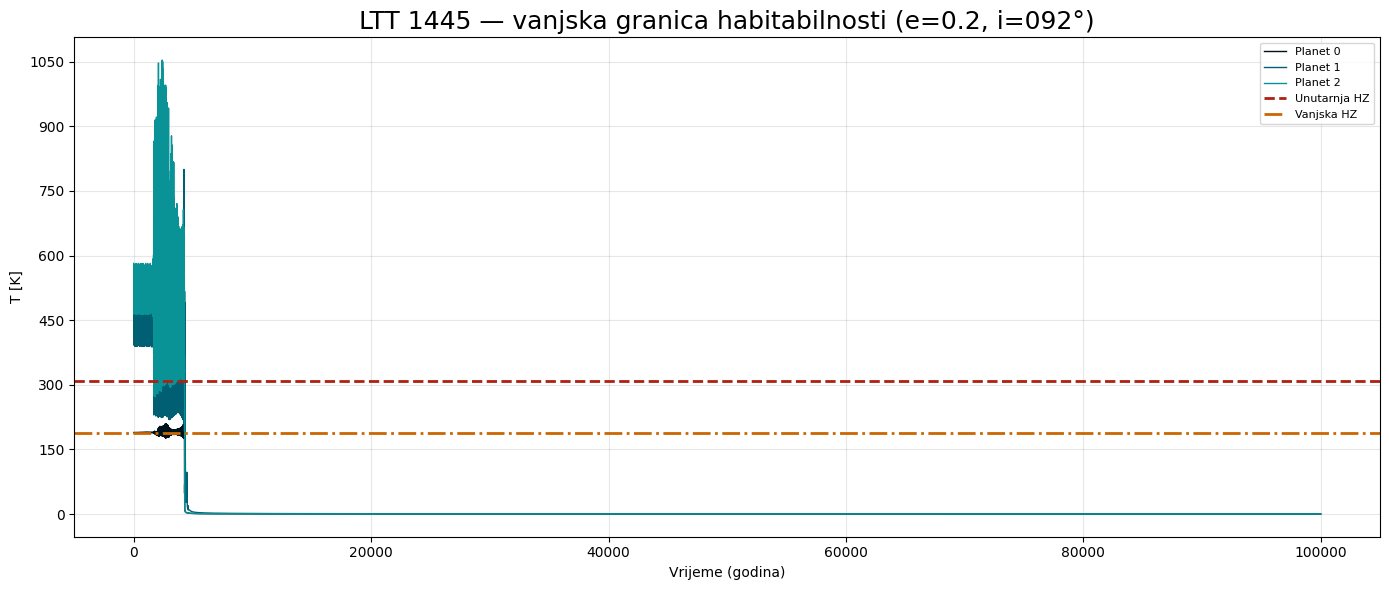

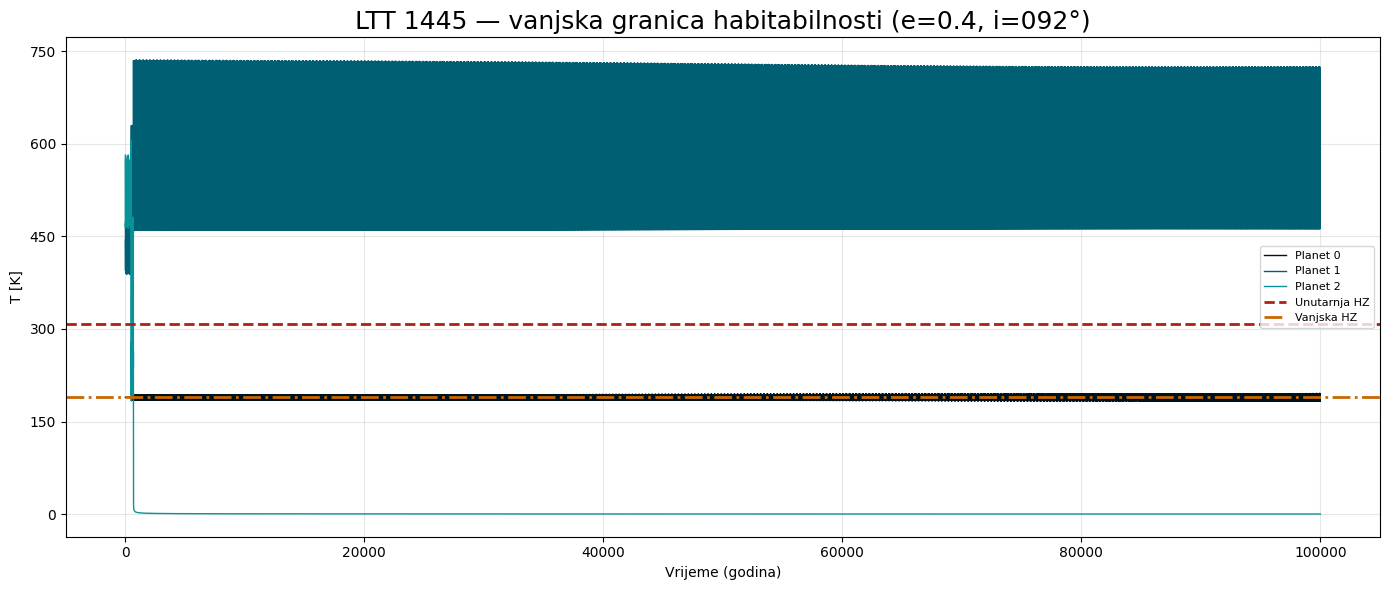

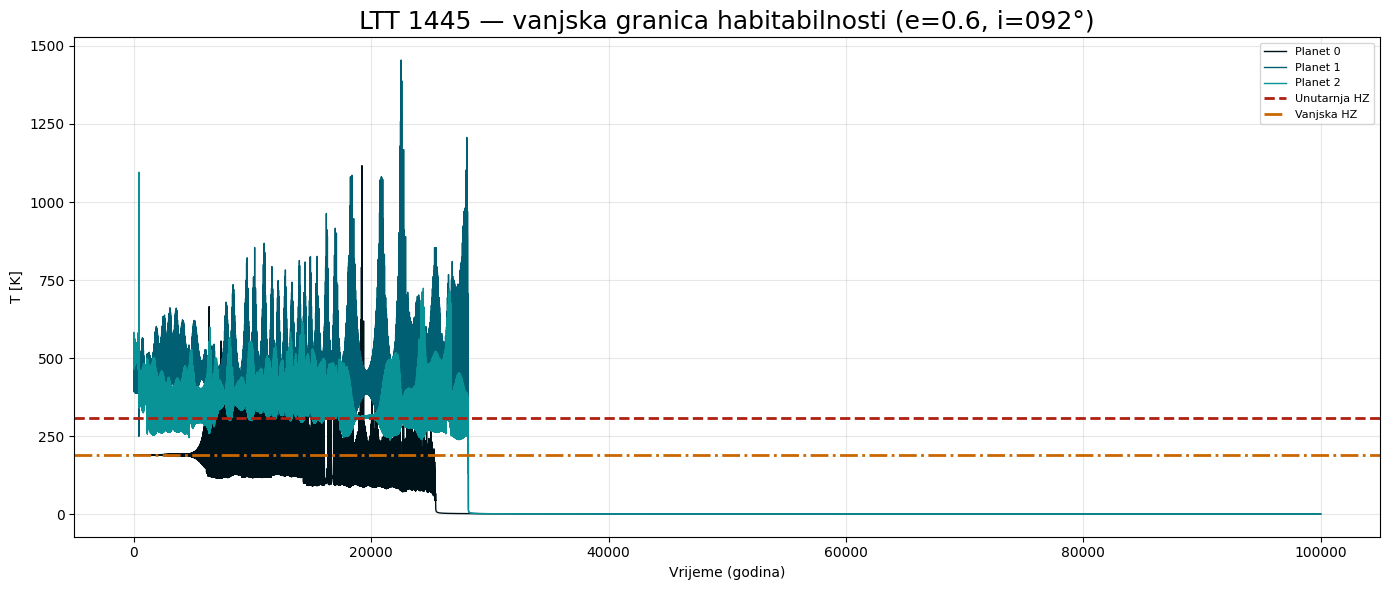

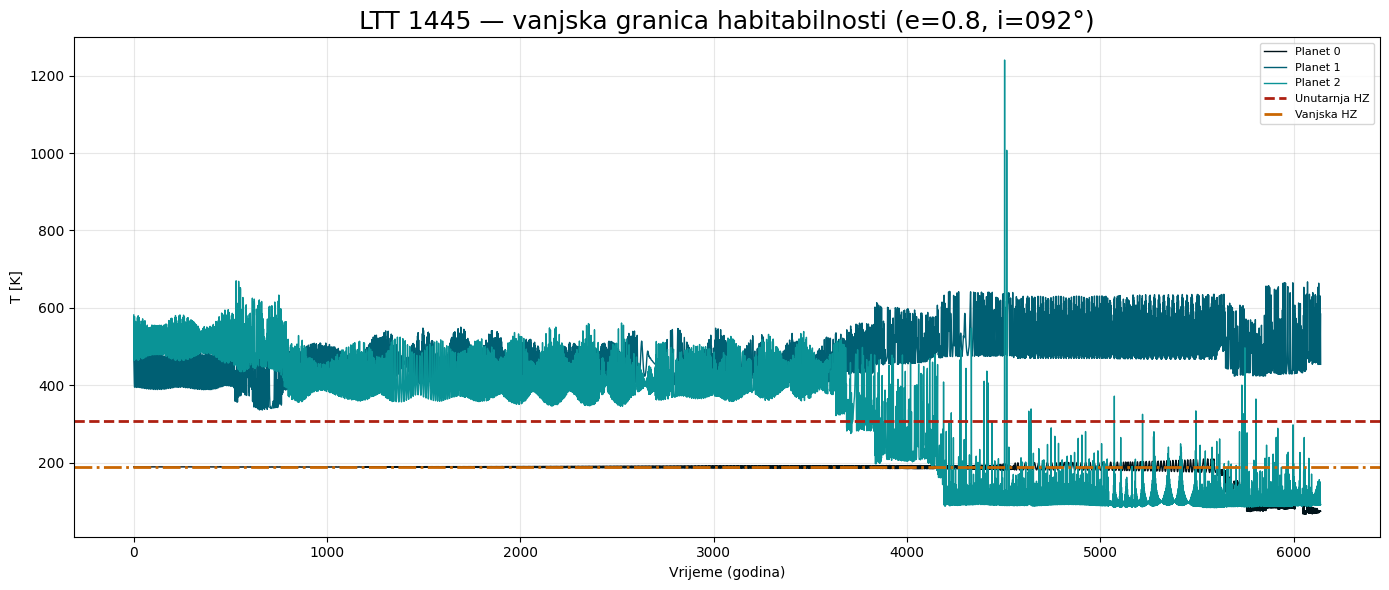

In [25]:
for i, cfg in enumerate(configs):
    path = cfg['output_file']
    if os.path.exists(path) and not os.path.exists('../plots_temp/'+cfg['experiment_name']+'.png'):
        plot_temperature(path, planet_smooth=1, save=cfg['experiment_name']+'.png')
    else:
        print('skipped', cfg['output_file'])


E0 = -3.8800460264569523
max |ΔE/E0| = 2.257275723291705e-05


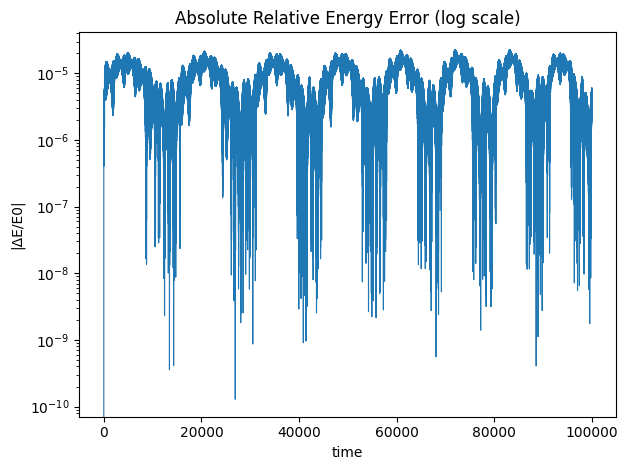

[-3.88004603 -3.88003372 -3.88002475 -3.88003303 -3.88004356 -3.88002773
 -3.88002511 -3.88004578 -3.88003348 -3.88002507]


In [ ]:
path = '../output/Gliese_667_observed_ev0.0_iv000.hdf5'

t, pos, mass, ptype, hz_inner_radius, hz_outer_radius, energy, temperature, in_hz, a, e, inc, s_eff_inner, s_eff_outer = load_hdf5_data(path)
star_idx, planet_idx, iA, iB, iC, mA, mB, r_com_bin = determine_system(mass, pos, ptype)

mask = np.isfinite(energy) & np.isfinite(t)
t = t[mask]
energy = energy[mask]

E0 = energy[0]
dE = energy - E0
rel = dE / abs(E0)

print("E0 =", E0)
print("max |ΔE/E0| =", np.max(np.abs(rel)))

plt.figure()
 
# Absolute relative error (paper-style)
plt.semilogy(t, np.abs(dE/E0), lw=0.8)
plt.xlabel("time")
plt.ylabel("|ΔE/E0|")
plt.title("Absolute Relative Energy Error (log scale)")

plt.tight_layout()
plt.show()


print(energy[:10])

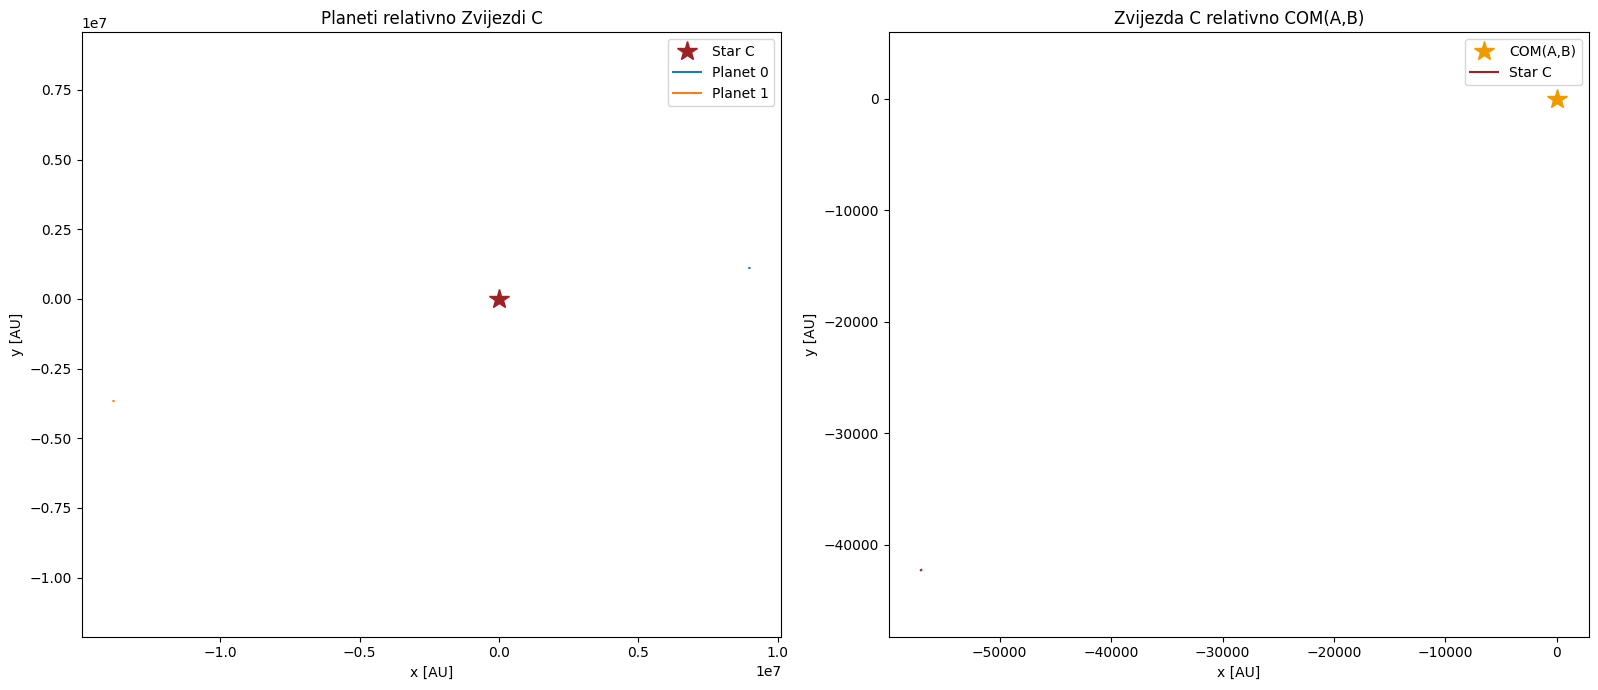

In [66]:
#mask = t <= t[0] + 50
mask = t >= t[-1] -50
star_idx, planet_idx, iA, iB, iC, mA, mB, r_com_bin = determine_system(mass, pos, ptype)

# Plot 1: Planets relative to star C
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.plot(0, 0, '*', color='#9b2226', ms=15, label='Star C')
ax.plot(pos[mask, 3, 0] - pos[mask, 2, 0], pos[mask, 3, 1] - pos[mask, 2, 1], label='Planet 0')
ax.plot(pos[mask, 4, 0] - pos[mask, 2, 0], pos[mask, 4, 1] - pos[mask, 2, 1], label='Planet 1')
ax.set_xlabel('x [AU]'); ax.set_ylabel('y [AU]')
ax.set_title('Planeti relativno Zvijezdi C')
ax.axis('equal'); ax.legend()

# Plot 2: Star C relative to COM(A,B)
com_AB = (mA * pos[mask, 0, :] + mB * pos[mask, 1, :]) / (mA + mB)
ax = axes[1]
ax.plot(0, 0, '*', color='#ee9b00', ms=15, label='COM(A,B)')
ax.plot(pos[mask, 2, 0] - com_AB[:, 0], pos[mask, 2, 1] - com_AB[:, 1], color='#9b2226', label='Star C')
ax.set_xlabel('x [AU]'); ax.set_ylabel('y [AU]')
ax.set_title('Zvijezda C relativno COM(A,B)')
ax.axis('equal'); ax.legend()

plt.tight_layout()
plt.show()
